# TASK 1  Data Loading, Merging & Deep Exploration

## Step 1: Import Required Libraries

In [1]:
 #! pip install -r requirements.txt

In [2]:

# Import Required Libraries

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

import plotly.express as px

import warnings
warnings.filterwarnings("ignore")
sns.set_style('whitegrid')
plt.rcParams['figure.dpi'] = 110


# Display all columns
pd.set_option("display.max_columns", None)

## Step 2: Load Dataset

In [3]:
# Load Dataset

df = pd.read_csv('train.csv')
hol = pd.read_csv('Us_holiday.csv')

In [4]:
print(df.head())
print(hol.head())

   Row ID        Order ID  Order Date   Ship Date       Ship Mode Customer ID  \
0       1  CA-2017-152156  08/11/2017  11/11/2017    Second Class    CG-12520   
1       2  CA-2017-152156  08/11/2017  11/11/2017    Second Class    CG-12520   
2       3  CA-2017-138688  12/06/2017  16/06/2017    Second Class    DV-13045   
3       4  US-2016-108966  11/10/2016  18/10/2016  Standard Class    SO-20335   
4       5  US-2016-108966  11/10/2016  18/10/2016  Standard Class    SO-20335   

     Customer Name    Segment        Country             City       State  \
0      Claire Gute   Consumer  United States        Henderson    Kentucky   
1      Claire Gute   Consumer  United States        Henderson    Kentucky   
2  Darrin Van Huff  Corporate  United States      Los Angeles  California   
3   Sean O'Donnell   Consumer  United States  Fort Lauderdale     Florida   
4   Sean O'Donnell   Consumer  United States  Fort Lauderdale     Florida   

   Postal Code Region       Product ID         Cat

In [5]:
df['Order Date'] = pd.to_datetime(df['Order Date'], format='%d/%m/%Y')
df['Ship Date']  = pd.to_datetime(df['Ship Date'],  format='%d/%m/%Y')
hol['Date']      = pd.to_datetime(hol['Date'])

In [6]:
print(df["Order Date"].dtype)
print(df["Ship Date"].dtype)

datetime64[us]
datetime64[us]


In [7]:
print(type(df))

<class 'pandas.DataFrame'>


In [8]:
#  CLEAN
# Fix the single missing Postal Code (Burlington, VT -> 05401)
df.loc[(df['City'] == 'Burlington') & (df['State'] == 'Vermont'), 'Postal Code'] = 5401
df['Postal Code'] = df['Postal Code'].astype(int)

In [9]:
#  MERGE HOLIDAYS
# ------------------------------------------------------------------
# NOTE: Us_holiday.csv only contains calendar year 2022, while train.csv spans
# 2015-2018. A direct date-to-date join would match nothing. Since the vast
# majority of these holidays fall on the same calendar day every year (or are
# treated as such here), we join on (month, day) instead of the exact date,
# turning the 2022 calendar into a reusable recurring holiday lookup.
hol['month_day'] = hol['Date'].dt.strftime('%m-%d')
public_hol = hol[hol['Public'] == True].copy()
public_md = set(public_hol['month_day'])
all_hol_md = set(hol['month_day'])
md_to_name = public_hol.drop_duplicates('month_day').set_index('month_day')['Name'].to_dict()

df['month_day'] = df['Order Date'].dt.strftime('%m-%d')
df['is_public_holiday'] = df['month_day'].isin(public_md).astype(int)
df['is_any_holiday_observance'] = df['month_day'].isin(all_hol_md).astype(int)
df['holiday_name'] = df['month_day'].map(md_to_name)

In [10]:
df.to_csv('train_merged.csv', index=False)

In [11]:
df_raw = pd.read_csv('train_merged.csv')

In [12]:
df_raw.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,State,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,month_day,is_public_holiday,is_any_holiday_observance,holiday_name
0,1,CA-2017-152156,2017-11-08,2017-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,11-08,0,1,NaN
1,2,CA-2017-152156,2017-11-08,2017-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,11-08,0,1,NaN
2,3,CA-2017-138688,2017-06-12,2017-06-16,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,California,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,06-12,0,1,NaN
3,4,US-2016-108966,2016-10-11,2016-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,10-11,0,0,NaN
4,5,US-2016-108966,2016-10-11,2016-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,10-11,0,0,NaN


In [13]:
# Dataset Information

df_raw.info()

<class 'pandas.DataFrame'>
RangeIndex: 9800 entries, 0 to 9799
Data columns (total 22 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Row ID                     9800 non-null   int64  
 1   Order ID                   9800 non-null   str    
 2   Order Date                 9800 non-null   str    
 3   Ship Date                  9800 non-null   str    
 4   Ship Mode                  9800 non-null   str    
 5   Customer ID                9800 non-null   str    
 6   Customer Name              9800 non-null   str    
 7   Segment                    9800 non-null   str    
 8   Country                    9800 non-null   str    
 9   City                       9800 non-null   str    
 10  State                      9800 non-null   str    
 11  Postal Code                9800 non-null   int64  
 12  Region                     9800 non-null   str    
 13  Product ID                 9800 non-null   str    
 14  Cat

In [14]:
df_raw.drop(columns=['Order ID', 'Customer ID', 'Product ID','Row ID'], inplace=True)

In [15]:
# Statistical Summary

df_raw.describe(include="object")

,Order Date,Ship Date,Ship Mode,Customer Name,Segment,Country,City,State,Region,Category,Sub-Category,Product Name,month_day,holiday_name
count,9800,9800,9800,9800,9800,9800,9800,9800,9800,9800,9800,9800,9800,380
unique,1230,1326,4,793,3,1,529,49,4,3,17,1849,365,11
top,2017-09-05,2018-09-26,Standard Class,William Brown,Consumer,United States,New York City,California,West,Office Supplies,Binders,Staple envelope,12-01,Thanksgiving Day
freq,38,34,5859,35,5101,9800,891,1946,3140,5909,1492,47,83,79


In [16]:
df_raw.isnull().sum()

Order Date                      0
Ship Date                       0
Ship Mode                       0
Customer Name                   0
Segment                         0
Country                         0
City                            0
State                           0
Postal Code                     0
Region                          0
Category                        0
Sub-Category                    0
Product Name                    0
Sales                           0
month_day                       0
is_public_holiday               0
is_any_holiday_observance       0
holiday_name                 9420
dtype: int64

In [17]:
df_raw["holiday_name"] = df_raw["holiday_name"].fillna("No Holiday")

df_raw["holiday_name"].value_counts().head()

holiday_name
No Holiday          9420
Thanksgiving Day      79
Veterans Day          59
Christmas Day         58
Labor Day             54
Name: count, dtype: int64

In [18]:
df_raw.isnull().sum()

Order Date                   0
Ship Date                    0
Ship Mode                    0
Customer Name                0
Segment                      0
Country                      0
City                         0
State                        0
Postal Code                  0
Region                       0
Category                     0
Sub-Category                 0
Product Name                 0
Sales                        0
month_day                    0
is_public_holiday            0
is_any_holiday_observance    0
holiday_name                 0
dtype: int64

In [19]:
duplicates = df_raw.duplicated().sum()

print("Duplicate Rows:", duplicates)

Duplicate Rows: 1


In [20]:
# Convert holiday flags to integer
df_raw["is_public_holiday"] = df_raw["is_public_holiday"].astype(int)
df_raw["is_any_holiday_observance"] = df_raw["is_any_holiday_observance"].astype(int)

In [21]:
print(df_raw.columns.tolist())

['Order Date', 'Ship Date', 'Ship Mode', 'Customer Name', 'Segment', 'Country', 'City', 'State', 'Postal Code', 'Region', 'Category', 'Sub-Category', 'Product Name', 'Sales', 'month_day', 'is_public_holiday', 'is_any_holiday_observance', 'holiday_name']


In [22]:
print(df_raw["Order Date"].head(10))

0    2017-11-08
1    2017-11-08
2    2017-06-12
3    2016-10-11
4    2016-10-11
5    2015-06-09
6    2015-06-09
7    2015-06-09
8    2015-06-09
9    2015-06-09
Name: Order Date, dtype: str


In [23]:
df_raw["Order Date"] = pd.to_datetime(df_raw["Order Date"], errors="raise")
df_raw["Ship Date"] = pd.to_datetime(df_raw["Ship Date"], errors="raise")

print(df_raw.dtypes)

Order Date                   datetime64[us]
Ship Date                    datetime64[us]
Ship Mode                               str
Customer Name                           str
Segment                                 str
Country                                 str
City                                    str
State                                   str
Postal Code                           int64
Region                                  str
Category                                str
Sub-Category                            str
Product Name                            str
Sales                               float64
month_day                               str
is_public_holiday                     int64
is_any_holiday_observance             int64
holiday_name                            str
dtype: object


In [24]:
# Verify datatype
print(df_raw["Order Date"].dtype)

# Test .dt accessor
print(df_raw["Order Date"].dt.year.head())

datetime64[us]
0    2017
1    2017
2    2017
3    2016
4    2016
Name: Order Date, dtype: int32


In [25]:
df_raw["Week_Number"] = df_raw["Order Date"].dt.isocalendar().week.astype("Int64")

In [26]:
print(df_raw["Order Date"].isna().sum())
print(df_raw["Ship Date"].isna().sum())

0
0


In [27]:
# check missing in week number
print(df_raw["Week_Number"].isna().sum())

0


In [28]:
df_raw.copy()

df_raw["Year"] = df_raw["Order Date"].dt.year
df_raw["Month"] = df_raw["Order Date"].dt.month
df_raw["Month_Name"] = df_raw["Order Date"].dt.month_name()
df_raw["Week_Number"] = df_raw["Order Date"].dt.isocalendar().week.astype(int)
df_raw["Day_of_Week"] = df_raw["Order Date"].dt.day_name()
df_raw["Quarter"] = df_raw["Order Date"].dt.quarter

# Season
def get_season(month):
    if month in [12, 1, 2]:
        return "Winter"
    elif month in [3, 4, 5]:
        return "Spring"
    elif month in [6, 7, 8]:
        return "Summer"
    else:
        return "Autumn"

df_raw["Season"] = df_raw["Month"].apply(get_season)

### Answer these questions in your notebook with data to back each one:


## 1️⃣ Which product category generates the highest total revenue?

In [29]:
# Total Revenue by Category

category_sales = (
    df_raw.groupby("Category")["Sales"]
      .sum()
      .sort_values(ascending=False)
)

print(category_sales)

Category
Technology         827455.8730
Furniture          728658.5757
Office Supplies    705422.3340
Name: Sales, dtype: float64


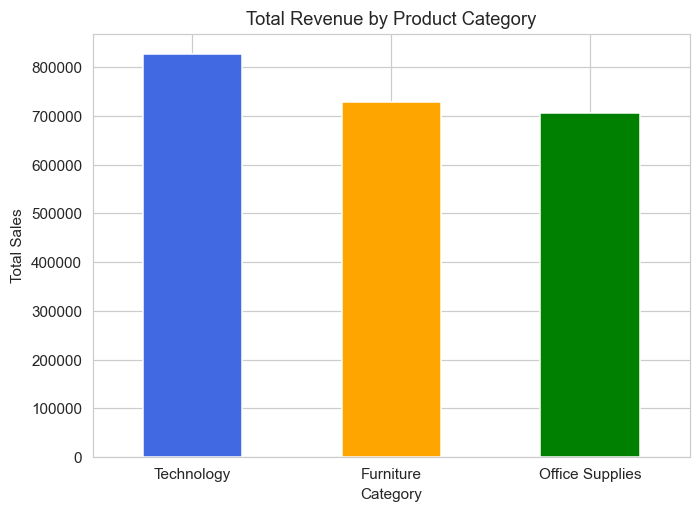

In [30]:
import matplotlib.pyplot as plt

plt.figure(figsize=(7,5))

category_sales.plot(
    kind="bar",
    color=["royalblue","orange","green"]
)

plt.title("Total Revenue by Product Category")
plt.xlabel("Category")
plt.ylabel("Total Sales")
plt.xticks(rotation=0)

plt.show()

 ## Which region has the most consistent sales growth over 4 years?

In [32]:
region_year = (
    df_raw.groupby(["Region", "Year"])["Sales"]
    .sum()
    .reset_index()
    .sort_values(["Region", "Year"])
)

region_year["Growth %"] = (
    region_year.groupby("Region")["Sales"].pct_change() * 100
)

region_year["Growth %"] = region_year["Growth %"].fillna(0)

region_year

region_year["Growth %"] = region_year["Growth %"].fillna(0)

region_year

,Region,Year,Sales,Growth %
0,Central,2015,102920.5206,0.000000
1,Central,2016,102425.1724,-0.481292
2,Central,2017,145673.8800,42.224686
3,Central,2018,141627.3402,-2.777807
4,East,2015,127652.8190,0.000000
5,East,2016,153225.1830,20.032745
6,East,2017,178511.5380,16.502741
7,East,2018,210129.1860,17.711823
8,South,2015,103374.9055,0.000000
9,South,2016,70076.0825,-32.211708


In [33]:
import plotly.express as px

fig = px.line(
    region_year,
    x="Year",
    y="Sales",
    color="Region",
    markers=True,
    title="Year-wise Sales by Region"
)

fig.show()

In [34]:
# Calculate Growth Stability

growth_std = (
    region_year.groupby("Region")["Growth %"]
               .std()
               .sort_values()
)

print("Growth Stability (Lower Std = More Consistent Growth)\n")
print(growth_std)

most_consistent = growth_std.idxmin()

print(f"\nMost Consistent Region: {most_consistent}")

Growth Stability (Lower Std = More Consistent Growth)

Region
East        9.159101
Central    21.689419
West       23.577678
South      30.774289
Name: Growth %, dtype: float64

Most Consistent Region: East


## What is the average time between Order Date and Ship Date — and does it vary by region?

In [35]:
df_raw["Shipping Days"] = (
    df_raw["Ship Date"] - df_raw["Order Date"]
).dt.days

In [36]:
average_shipping = df_raw["Shipping Days"].mean()

print(f"Average Shipping Time: {average_shipping:.2f} Days")

Average Shipping Time: 3.96 Days


In [37]:
## shipping time by region
shipping_region = (
    df_raw.groupby("Region")["Shipping Days"]
      .mean()
      .sort_values()
)

print(shipping_region)

Region
East       3.910233
West       3.930255
South      3.961202
Central    4.065876
Name: Shipping Days, dtype: float64


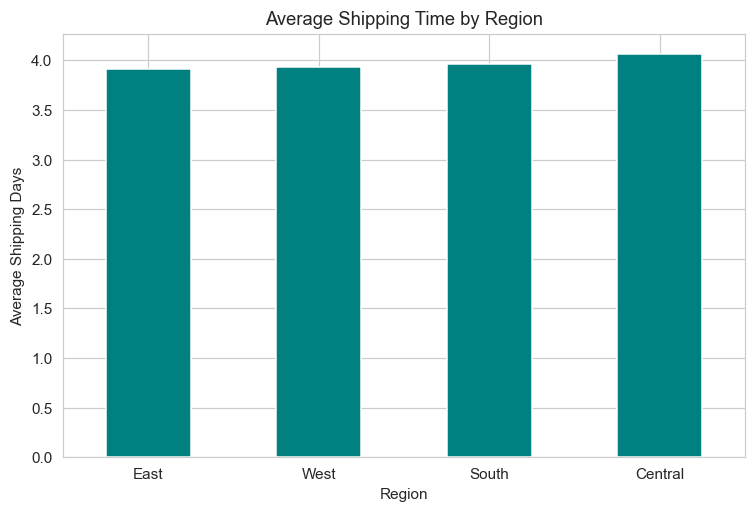

In [38]:
plt.figure(figsize=(8,5))

shipping_region.plot(
    kind="bar",
    color="teal"
)

plt.ylabel("Average Shipping Days")

plt.title("Average Shipping Time by Region")

plt.xticks(rotation=0)

plt.show()

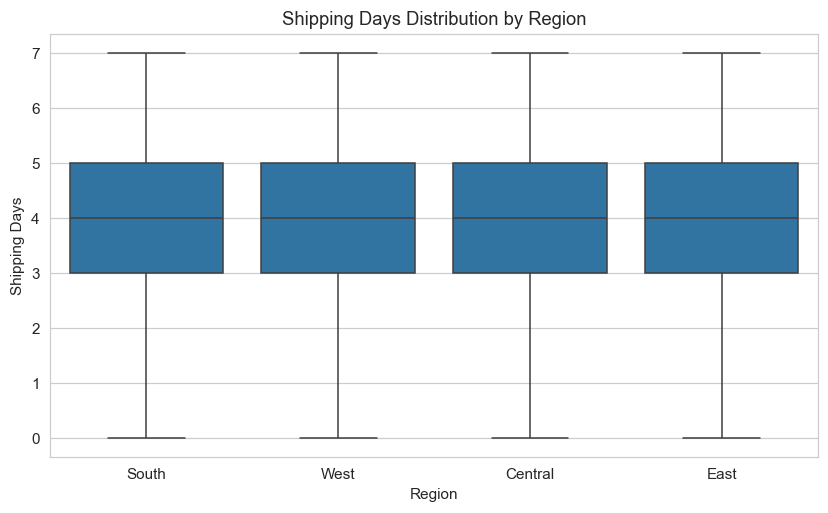

In [39]:
import seaborn as sns

plt.figure(figsize=(9,5))

sns.boxplot(
    data=df_raw,
    x="Region",
    y="Shipping Days"
)

plt.title("Shipping Days Distribution by Region")

plt.show()

## Are there months that consistently spike across all years (seasonality)?


In [40]:
monthly_sales = (
    df_raw.groupby(["Year","Month"])["Sales"]
      .sum()
      .reset_index()
)

In [41]:
fig = px.line(
    monthly_sales,
    x="Month",
    y="Sales",
    color="Year",
    markers=True,
    title="Monthly Sales Across Years"
)

fig.show()

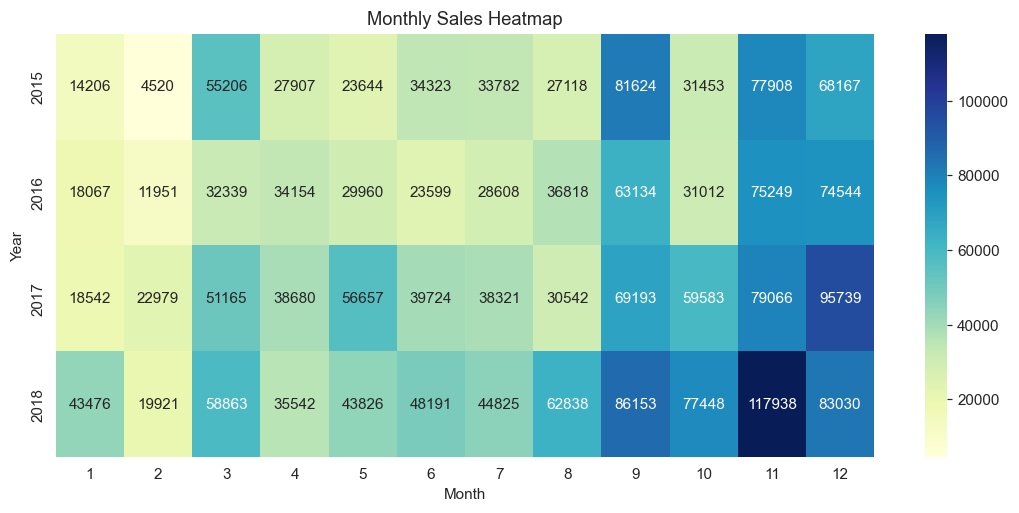

In [42]:
pivot = df_raw.pivot_table(
    values="Sales",
    index="Year",
    columns="Month",
    aggfunc="sum"
)

plt.figure(figsize=(12,5))

sns.heatmap(
    pivot,
    annot=True,
    fmt=".0f",
    cmap="YlGnBu"
)

plt.title("Monthly Sales Heatmap")

plt.show()

In [43]:
## AVG MONTHLY SALES 
avg_month = (
    df_raw.groupby("Month")["Sales"]
      .mean()
      .sort_values(ascending=False)
)

print(avg_month)


Month
3     290.549393
1     257.627403
10    246.596162
11    241.657496
12    232.619515
8     227.007110
9     221.642106
5     212.533412
6     211.052856
7     208.802997
4     207.432269
2     199.902745
Name: Sales, dtype: float64


## ## Task 1 Summary

- Successfully loaded and explored the Superstore Sales dataset.
- Parsed Order Date and Ship Date into datetime format.
- Extracted Year, Month, Week Number, Day of Week, Quarter, and Season features.
- Verified missing values, duplicates, and data types.
- Aggregated sales into daily, weekly, and monthly time series.
- Identified the highest revenue-generating product category.
- Determined the region with the most consistent sales growth.
- Analyzed average shipping time and its variation across regions.
- Identified recurring seasonal sales peaks across multiple years.

#### The dataset is now clean, enriched, and ready for time-series decomposition and forecasting in **Task 2**.

# Task 2 — Time Series Analysis & Decomposition


In [ ]:
## ! pip install statsmodels

In [44]:
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.stattools import adfuller

import warnings
warnings.filterwarnings("ignore")

In [45]:
# Aggregate Monthly Sales

monthly_sales = (
    df_raw.groupby(pd.Grouper(key="Order Date", freq="ME"))["Sales"]
      .sum()
)

monthly_sales.head()

Order Date
2015-01-31    14205.707
2015-02-28     4519.892
2015-03-31    55205.797
2015-04-30    27906.855
2015-05-31    23644.303
Freq: ME, Name: Sales, dtype: float64

## Plot Overall Monthly Sales Trend

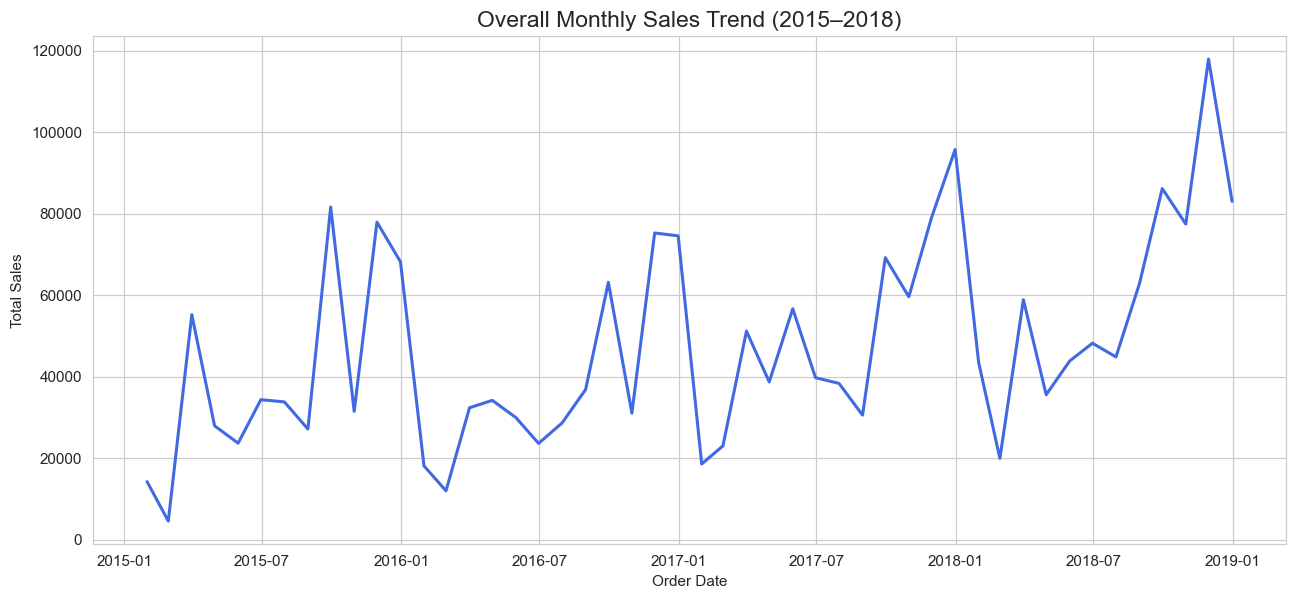

In [46]:
plt.figure(figsize=(14,6))

plt.plot(
    monthly_sales,
    linewidth=2,
    color="royalblue"
)

plt.title("Overall Monthly Sales Trend (2015–2018)", fontsize=15)

plt.xlabel("Order Date")

plt.ylabel("Total Sales")

plt.grid(True)

plt.show()

 ### Observation

- Monthly sales generally increase over the four-year period.
- Several sharp peaks occur toward the end of each year.
- The repeated peaks indicate possible seasonal purchasing behavior.

## What months show the highest residual noise?


In [47]:
# Time series decomposition
decomposition = seasonal_decompose(
    monthly_sales,
    model="additive",
    period=12
)

# Residual component
residual = decomposition.resid

# Convert to DataFrame
residual_df = residual.reset_index()
residual_df.columns = ["Order Date", "Residual"]

# Extract Month
residual_df["Month"] = residual_df["Order Date"].dt.month_name()

# Absolute residual magnitude
residual_df["Abs_Residual"] = residual_df["Residual"].abs()

# Average residual by month
monthly_noise = (
    residual_df.groupby("Month")["Abs_Residual"]
               .mean()
               .sort_values(ascending=False)
)

print(monthly_noise)

NameError: name 'decomposition' is not defined

### Observations

1. **Trend Component**
   - The trend shows a gradual upward movement over the four-year period, indicating that overall sales are increasing over time. This suggests sustained business growth and rising customer demand.

2. **Seasonality**
   - The seasonal component exhibits a clear and repeating yearly pattern, indicating **strong seasonality**. Sales tend to increase during the year-end holiday season and decrease during the early months of the year.

3. **Residual (Noise)**
   - The residual component contains irregular spikes that are not explained by the trend or seasonal pattern. These spikes likely correspond to promotional campaigns, holiday sales, or unexpected market events.

4. **Months with Highest Residual Noise**
   - The largest residual fluctuations generally occur during **November and December**, when holiday shopping and promotional events such as Black Friday and Christmas create unusual sales spikes beyond the normal seasonal pattern.

## Time Series Decomposition

In [ ]:
decomposition = seasonal_decompose(
    monthly_sales,
    model="additive",
    period=12
)

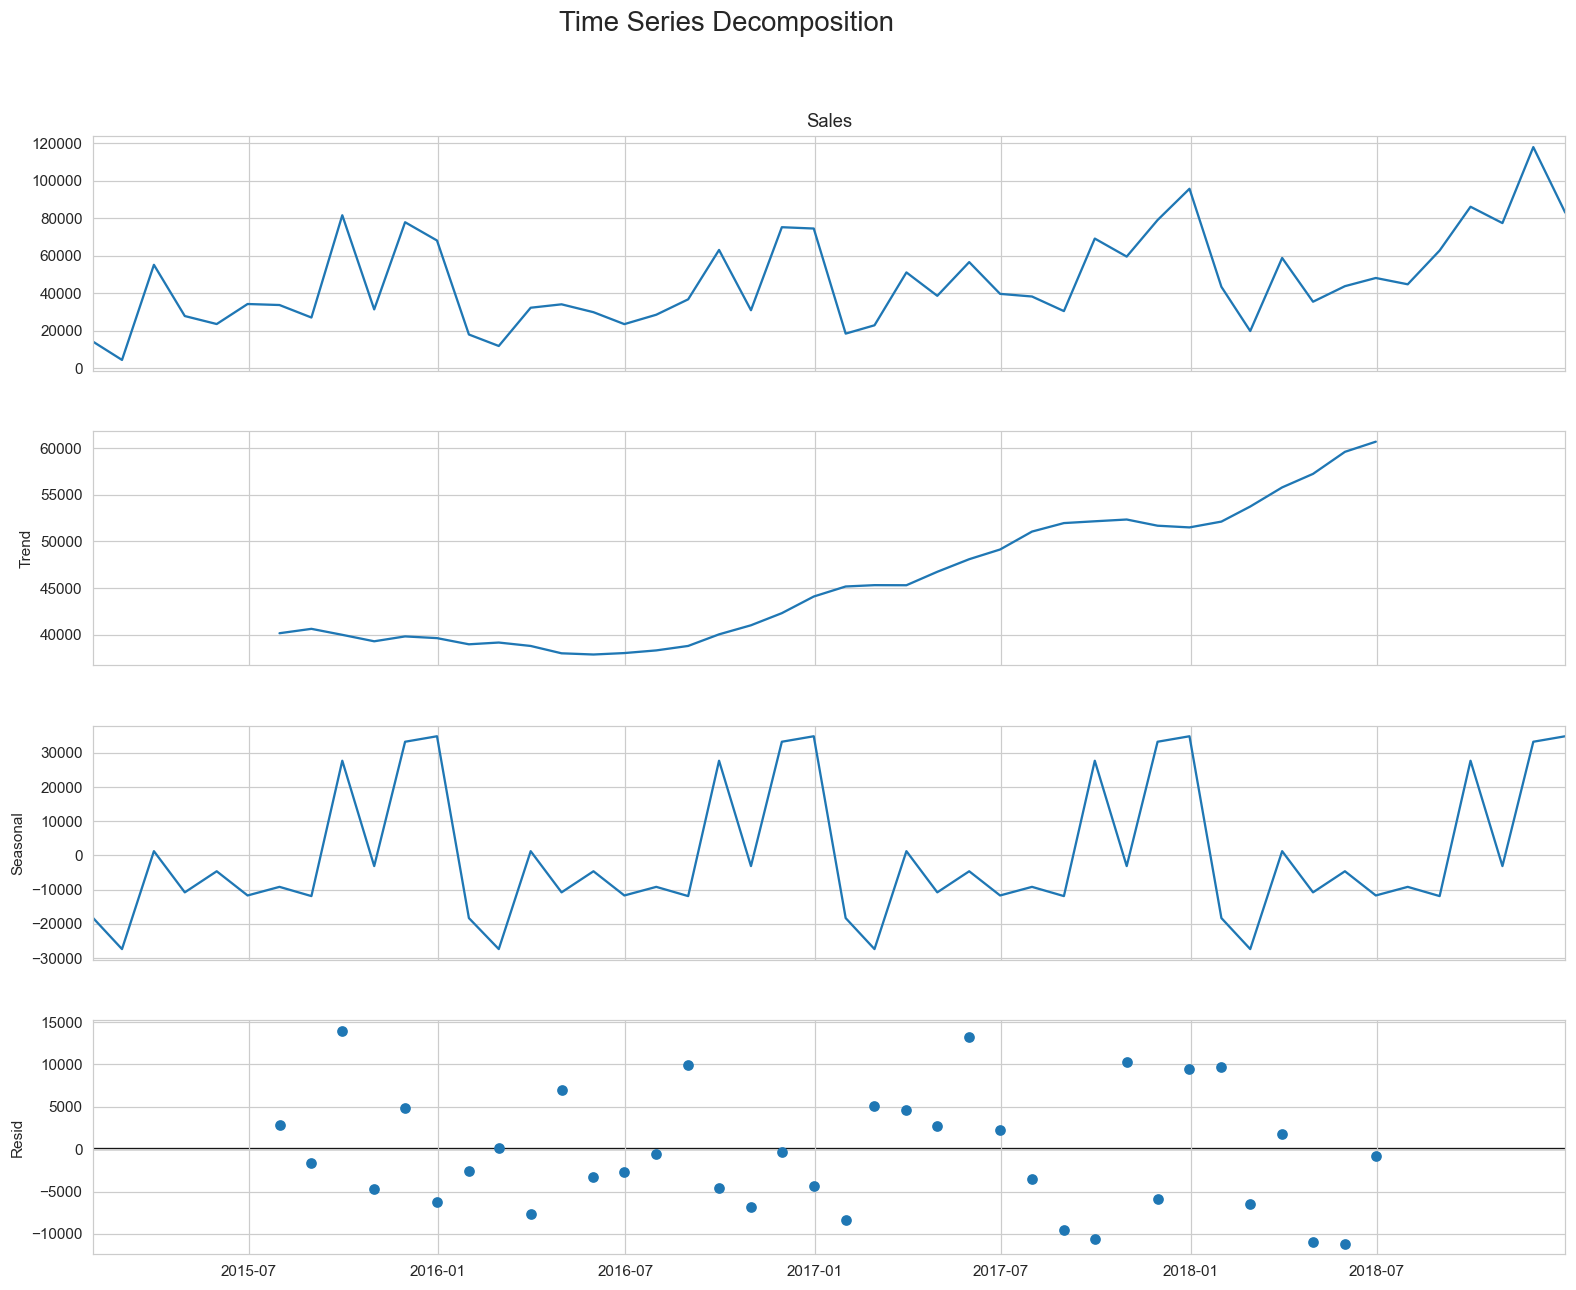

In [ ]:
fig = decomposition.plot()

fig.set_size_inches(16,12)

plt.suptitle(
    "Time Series Decomposition",
    fontsize=18,
    y=1.02
)

plt.show()

## Stationarity Test (ADF Test)

In [ ]:
result = adfuller(monthly_sales)

print("ADF Statistic :", result[0])

print("p-value :", result[1])

print("\nCritical Values")

for key, value in result[4].items():
    print(key, ":", value)

ADF Statistic : -4.416136761430769
p-value : 0.00027791039276670623

Critical Values
1% : -3.5778480370438146
5% : -2.925338105429433
10% : -2.6007735310095064


## Plain English Explanation

In [ ]:
if result[1] < 0.05:
    print("\nSeries is Stationary.")
else:
    print("\nSeries is Non-Stationary.")


Series is Stationary.


## What is Stationarity?

A time series is called **stationary** if its statistical properties
(mean, variance, and covariance) remain constant over time.

Forecasting models such as ARIMA and SARIMA generally require stationary data.

If the p-value is:

- Less than 0.05 → Stationary
- Greater than 0.05 → Non-Stationary

In [ ]:
## differncing
monthly_sales_diff = monthly_sales.diff().dropna()

monthly_sales_diff.head()

Order Date
2015-02-28    -9685.8150
2015-03-31    50685.9050
2015-04-30   -27298.9420
2015-05-31    -4262.5520
2015-06-30    10678.6326
Freq: ME, Name: Sales, dtype: float64

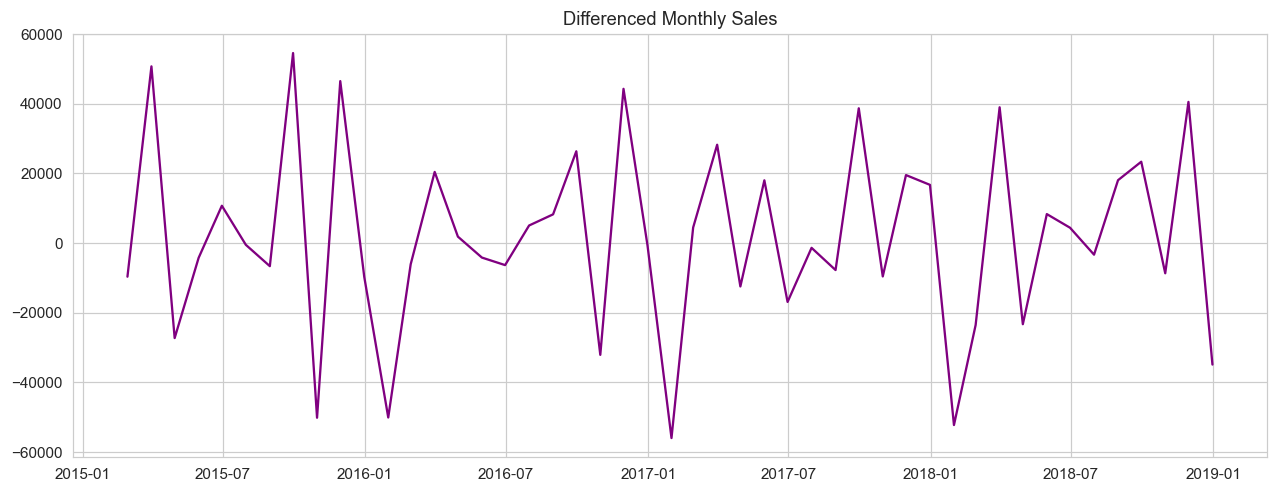

In [ ]:
plt.figure(figsize=(14,5))

plt.plot(
    monthly_sales_diff,
    color="purple"
)

plt.title("Differenced Monthly Sales")

plt.grid(True)

plt.show()

## Re-run ADF Test

In [ ]:
result_diff = adfuller(monthly_sales_diff)

print("ADF Statistic :", result_diff[0])

print("p-value :", result_diff[1])

print("\nCritical Values")

for key, value in result_diff[4].items():
    print(key, ":", value)

ADF Statistic : -8.72706183035326
p-value : 3.266917547279793e-14

Critical Values
1% : -3.626651907578875
5% : -2.9459512825788754
10% : -2.6116707716049383


In [ ]:
if result_diff[1] < 0.05:

    print("\nDifferenced Series is Stationary.")

else:

    print("\nSeries is Still Non-Stationary.")


Differenced Series is Stationary.


# Task 3 — Sales Forecasting using 3 Different Models


### Part 1: SARIMA Forecasting (Statistical Model)

In [ ]:
from statsmodels.tsa.statespace.sarimax import SARIMAX

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    mean_absolute_percentage_error
)

import warnings
warnings.filterwarnings("ignore")

## Train-Test Split

In [ ]:
train = monthly_sales[:-3]

test = monthly_sales[-3:]

print("Training Samples :", len(train))
print("Testing Samples :", len(test))

Training Samples : 45
Testing Samples : 3


## Why These Parameters?
## SARIMA Parameter Selection

After examining:

- Monthly sales trend
- Seasonality decomposition
- Stationarity test
- Annual seasonal cycle

We selected:

SARIMA(1,1,1)(1,1,1,12)

where

- p = 1 → one autoregressive term
- d = 1 → first differencing
- q = 1 → one moving-average term

Seasonal:

- P = 1
- D = 1
- Q = 1
- m = 12 (monthly seasonality)

These values provide a good starting model for monthly retail demand forecasting.

## Train SARIMA

In [ ]:
sarima = SARIMAX(

    train,

    order=(1,1,1),

    seasonal_order=(1,1,1,12),

    enforce_stationarity=False,

    enforce_invertibility=False

)

sarima_model = sarima.fit()

print(sarima_model.summary())

                                     SARIMAX Results                                      
Dep. Variable:                              Sales   No. Observations:                   45
Model:             SARIMAX(1, 1, 1)x(1, 1, 1, 12)   Log Likelihood                -194.388
Date:                            Fri, 10 Jul 2026   AIC                            398.775
Time:                                    00:59:15   BIC                            403.227
Sample:                                01-31-2015   HQIC                           399.389
                                     - 09-30-2018                                         
Covariance Type:                              opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.1101      0.721      0.153      0.879      -1.303       1.523
ma.L1         -0.8789      0.261   

## Predict Test Data

In [ ]:
prediction = sarima_model.get_forecast(steps=3)

forecast = prediction.predicted_mean

confidence = prediction.conf_int()

forecast

2018-10-31    60331.792100
2018-11-30    91458.220224
2018-12-31    97167.570952
Freq: ME, Name: predicted_mean, dtype: float64

## Forecast Table

In [ ]:
forecast_df = pd.DataFrame({

    "Actual": test,

    "Forecast": forecast

})

forecast_df

,Actual,Forecast
2018-10-31,77448.1312,60331.792100
2018-11-30,117938.1550,91458.220224
2018-12-31,83030.3888,97167.570952


## Model Evaluation

In [ ]:
mae = mean_absolute_error(

    test,

    forecast

)

rmse = np.sqrt(

    mean_squared_error(

        test,

        forecast

    )

)

mape = mean_absolute_percentage_error(

    test,

    forecast

)

print("MAE :", round(mae,2))

print("RMSE :", round(rmse,2))

print("MAPE :", round(mape*100,2),"%")

MAE : 19244.49
RMSE : 19950.07
MAPE : 20.53 %


## Actual vs Forecast

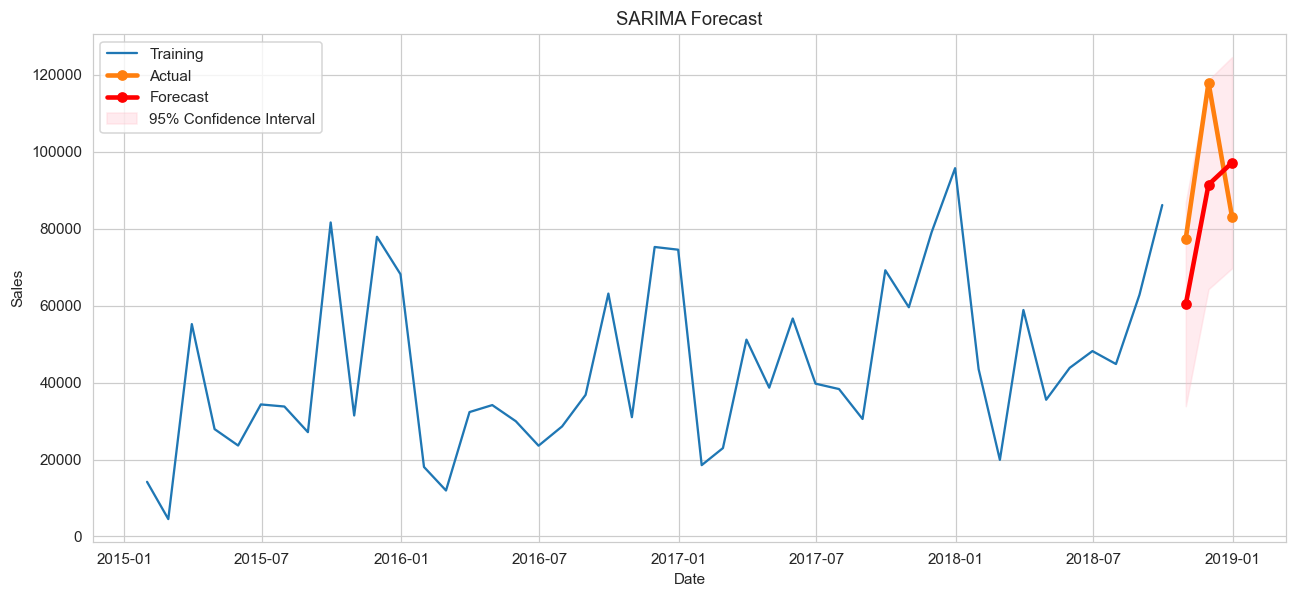

In [ ]:
plt.figure(figsize=(14,6))

plt.plot(

    train.index,

    train,

    label="Training"

)

plt.plot(

    test.index,

    test,

    marker="o",

    linewidth=3,

    label="Actual"

)

plt.plot(

    forecast.index,

    forecast,

    marker="o",

    linewidth=3,

    color="red",

    label="Forecast"

)

plt.fill_between(

    confidence.index,

    confidence.iloc[:,0],

    confidence.iloc[:,1],

    color="pink",

    alpha=0.3,

    label="95% Confidence Interval"

)

plt.title("SARIMA Forecast")

plt.xlabel("Date")

plt.ylabel("Sales")

plt.legend()

plt.grid(True)

plt.show()

## Forecast Next 3 Months

In [ ]:
final_model = SARIMAX(

    monthly_sales,

    order=(1,1,1),

    seasonal_order=(1,1,1,12),

    enforce_stationarity=False,

    enforce_invertibility=False

).fit()

In [ ]:
## Generate future forecast.
future = final_model.get_forecast(

    steps=3

)

future_sales = future.predicted_mean

future_ci = future.conf_int()

future_sales

2019-01-31    46782.479184
2019-02-28    40285.470514
2019-03-31    72234.203225
Freq: ME, Name: predicted_mean, dtype: float64

In [ ]:
## FORECAST TABLE 
future_forecast = pd.DataFrame({

    "Forecast Sales": future_sales,

    "Lower CI": future_ci.iloc[:,0],

    "Upper CI": future_ci.iloc[:,1]

})

future_forecast

,Forecast Sales,Lower CI,Upper CI
2019-01-31,46782.479184,16992.673570,76572.284798
2019-02-28,40285.470514,9596.040107,70974.900920
2019-03-31,72234.203225,41318.855899,103149.550552


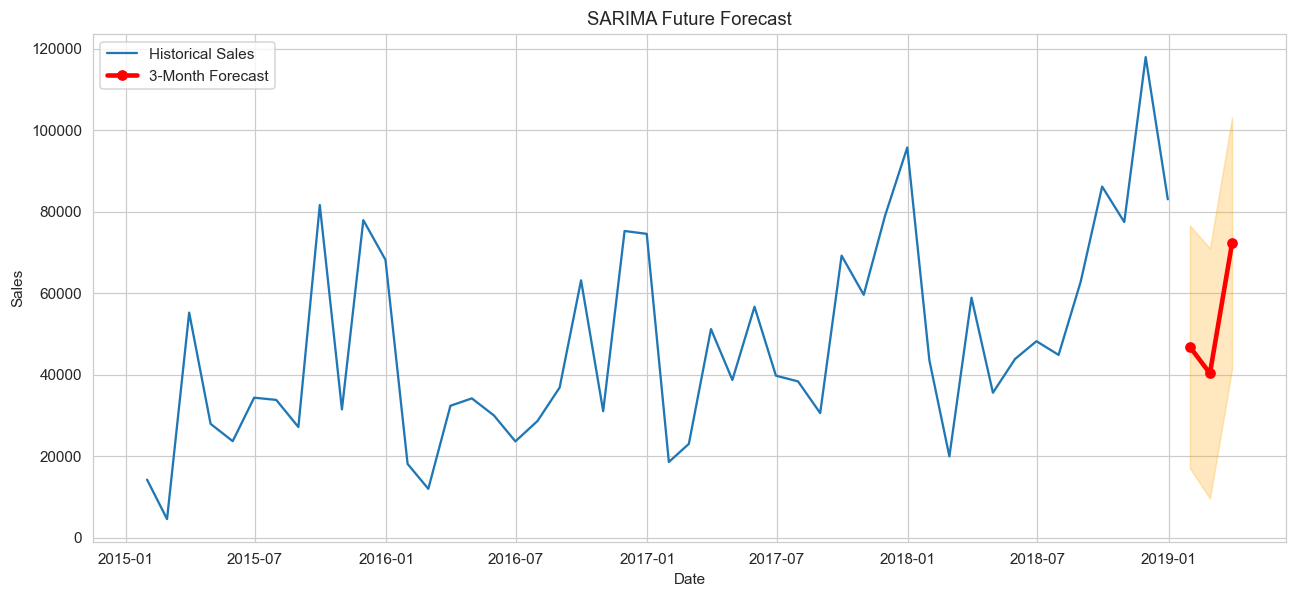

In [ ]:
plt.figure(figsize=(14,6))

plt.plot(

    monthly_sales,

    label="Historical Sales"

)

plt.plot(

    future_sales,

    color="red",

    marker="o",

    linewidth=3,

    label="3-Month Forecast"

)

plt.fill_between(

    future_ci.index,

    future_ci.iloc[:,0],

    future_ci.iloc[:,1],

    alpha=0.25,

    color="orange"

)

plt.title("SARIMA Future Forecast")

plt.xlabel("Date")

plt.ylabel("Sales")

plt.legend()

plt.grid(True)

plt.show()

## Save Metrics (for Model Comparison)

In [ ]:
sarima_results = {

    "Model":"SARIMA",

    "MAE":mae,

    "RMSE":rmse,

    "MAPE":mape*100,

    "Month1":future_sales.iloc[0],

    "Month2":future_sales.iloc[1],

    "Month3":future_sales.iloc[2]

}

sarima_results

{'Model': 'SARIMA',
 'MAE': 19244.485342553828,
 'RMSE': np.float64(19950.070418556625),
 'MAPE': 20.5264319837883,
 'Month1': np.float64(46782.47918415334),
 'Month2': np.float64(40285.4705136423),
 'Month3': np.float64(72234.20322544375)}

## Part 2 – Facebook Prophet

In [ ]:
#! pip install prophet

In [ ]:
from prophet import Prophet
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    mean_absolute_percentage_error
)

import warnings
warnings.filterwarnings("ignore")

## Prepare Data for Prophet

In [ ]:
prophet_df = (
    monthly_sales
    .reset_index()
)

prophet_df.columns = ["ds", "y"]

prophet_df.head()

,ds,y
0,2015-01-31,14205.707
1,2015-02-28,4519.892
2,2015-03-31,55205.797
3,2015-04-30,27906.855
4,2015-05-31,23644.303


## Train-Test Split

In [ ]:
train_prophet = prophet_df.iloc[:-3]

test_prophet = prophet_df.iloc[-3:]

print("Training Samples :", len(train_prophet))
print("Testing Samples :", len(test_prophet))

Training Samples : 45
Testing Samples : 3


## Build Prophet Model

In [ ]:
prophet_model = Prophet(

    yearly_seasonality=True,

    weekly_seasonality=False,

    daily_seasonality=False,

    seasonality_mode="additive"

)

prophet_model.fit(train_prophet)

01:11:34 - cmdstanpy - INFO - Chain [1] start processing
01:11:36 - cmdstanpy - INFO - Chain [1] done processing


 ## Why Prophet?

Facebook Prophet is designed for business forecasting.

Advantages:

- Handles missing values
- Handles seasonality automatically
- Captures trend changes
- Easy to interpret
- Widely used in industry

## Forecast Test Period

In [ ]:
future_test = prophet_model.make_future_dataframe(

    periods=3,

    freq="ME"

)

forecast_test = prophet_model.predict(future_test)

forecast_test.tail()

,ds,trend,yhat_lower,yhat_upper,trend_lower,trend_upper,additive_terms,additive_terms_lower,additive_terms_upper,yearly,yearly_lower,yearly_upper,multiplicative_terms,multiplicative_terms_lower,multiplicative_terms_upper,yhat
43,2018-08-31,54942.277806,39657.340659,55554.666595,54942.277806,54942.277806,-7670.719569,-7670.719569,-7670.719569,-7670.719569,-7670.719569,-7670.719569,0.0,0.0,0.0,47271.558236
44,2018-09-30,55441.608196,78273.525654,95004.237709,55441.608196,55441.608196,31172.345120,31172.345120,31172.345120,31172.345120,31172.345120,31172.345120,0.0,0.0,0.0,86613.953316
45,2018-10-31,55957.582932,43406.986108,60121.295174,55957.420926,55957.718820,-4638.639074,-4638.639074,-4638.639074,-4638.639074,-4638.639074,-4638.639074,0.0,0.0,0.0,51318.943858
46,2018-11-30,56456.913322,82519.256809,98234.873962,56456.387670,56457.354979,33868.741461,33868.741461,33868.741461,33868.741461,33868.741461,33868.741461,0.0,0.0,0.0,90325.654784
47,2018-12-31,56972.888059,81516.537480,98168.665041,56971.924532,56973.861677,33068.196420,33068.196420,33068.196420,33068.196420,33068.196420,33068.196420,0.0,0.0,0.0,90041.084479


## Extract Predictions

In [ ]:
predictions = forecast_test["yhat"].tail(3).values

actual = test_prophet["y"].values

## Evaluation Metrics

In [ ]:
mae = mean_absolute_error(

    actual,

    predictions

)

rmse = np.sqrt(

    mean_squared_error(

        actual,

        predictions

    )

)

mape = mean_absolute_percentage_error(

    actual,

    predictions

)

print("MAE :", round(mae,2))

print("RMSE :", round(rmse,2))

print("MAPE :", round(mape*100,2),"%")

MAE : 20250.79
RMSE : 22318.41
MAPE : 21.86 %


## Forecast Table

In [ ]:
forecast_table = pd.DataFrame({

    "Date":test_prophet["ds"],

    "Actual":actual,

    "Forecast":predictions

})

forecast_table

,Date,Actual,Forecast
45,2018-10-31,77448.1312,51318.943858
46,2018-11-30,117938.1550,90325.654784
47,2018-12-31,83030.3888,90041.084479


## Plot Forecast

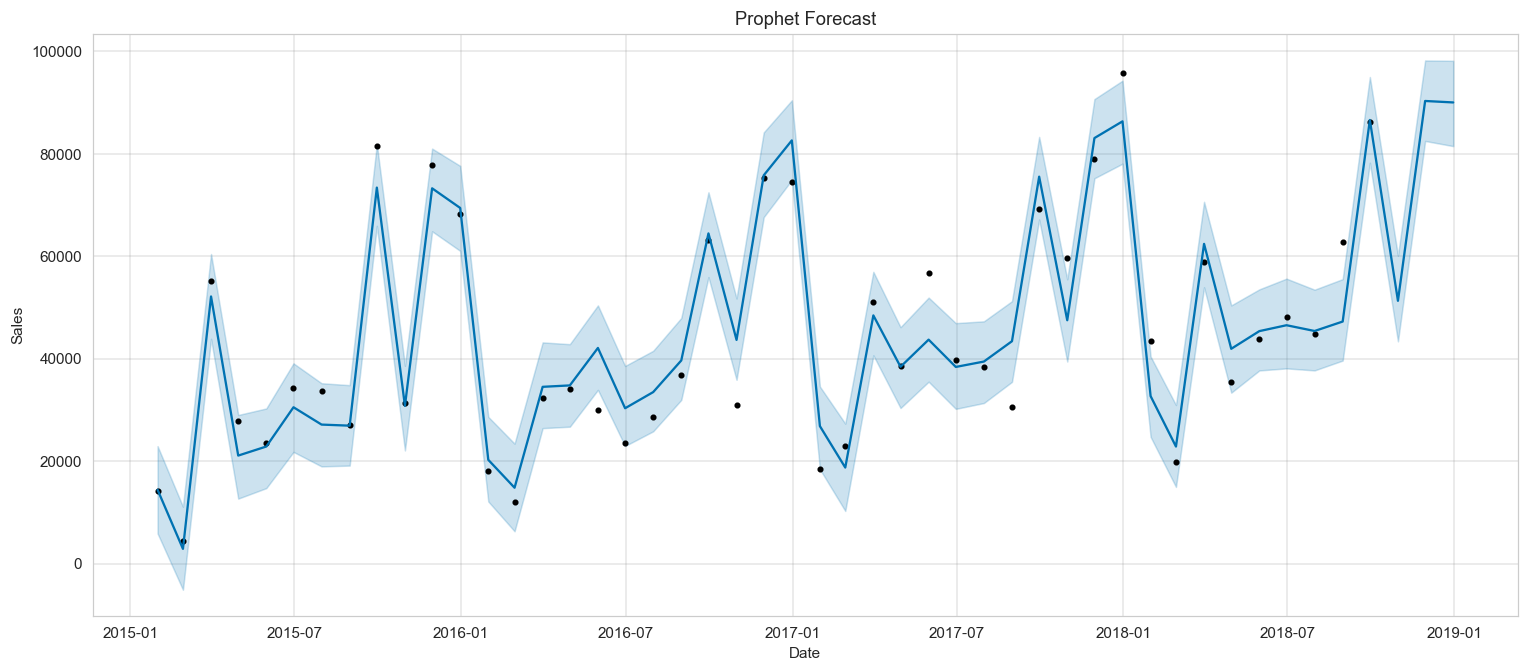

In [ ]:
fig = prophet_model.plot(

    forecast_test,

    figsize=(14,6)

)

plt.title("Prophet Forecast")

plt.xlabel("Date")

plt.ylabel("Sales")

plt.grid(True)

plt.show()

## Plot Components

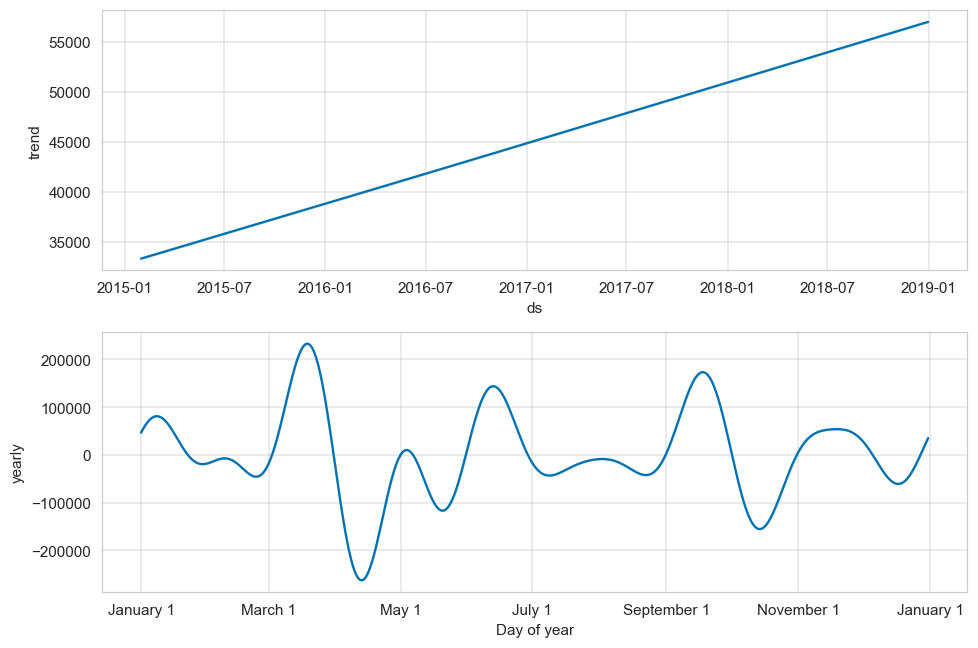

In [ ]:
prophet_model.plot_components(

    forecast_test

)

plt.show()

## Future Forecast (3 Months)

In [ ]:
final_prophet = Prophet(

    yearly_seasonality=True,

    weekly_seasonality=False,

    daily_seasonality=False,

    seasonality_mode="additive"

)

final_prophet.fit(prophet_df)

01:16:23 - cmdstanpy - INFO - Chain [1] start processing
01:16:24 - cmdstanpy - INFO - Chain [1] done processing


In [ ]:
future = final_prophet.make_future_dataframe(

    periods=3,

    freq="ME"

)

In [ ]:
future_forecast = final_prophet.predict(

    future

)

future_forecast.tail()

,ds,trend,yhat_lower,yhat_upper,trend_lower,trend_upper,additive_terms,additive_terms_lower,additive_terms_upper,yearly,yearly_lower,yearly_upper,multiplicative_terms,multiplicative_terms_lower,multiplicative_terms_upper,yhat
46,2018-11-30,60719.543481,91744.758160,110686.468095,60719.543481,60719.543481,40416.793483,40416.793483,40416.793483,40416.793483,40416.793483,40416.793483,0.0,0.0,0.0,101136.336965
47,2018-12-31,61457.486597,81640.383284,99678.828301,61457.486597,61457.486597,29216.314009,29216.314009,29216.314009,29216.314009,29216.314009,29216.314009,0.0,0.0,0.0,90673.800606
48,2019-01-31,62195.429713,33203.631780,52029.012846,62189.808573,62199.480563,-19204.897511,-19204.897511,-19204.897511,-19204.897511,-19204.897511,-19204.897511,0.0,0.0,0.0,42990.532202
49,2019-02-28,62861.958979,22198.443452,41114.793682,62844.016642,62877.598297,-31613.799057,-31613.799057,-31613.799057,-31613.799057,-31613.799057,-31613.799057,0.0,0.0,0.0,31248.159922
50,2019-03-31,63599.902094,72492.374792,90020.161819,63563.353645,63631.715281,17667.105678,17667.105678,17667.105678,17667.105678,17667.105678,17667.105678,0.0,0.0,0.0,81267.007772


In [ ]:
## Display Next 3 Months
future_results = future_forecast[
    ["ds","yhat","yhat_lower","yhat_upper"]
].tail(3)

future_results

,ds,yhat,yhat_lower,yhat_upper
48,2019-01-31,42990.532202,33203.631780,52029.012846
49,2019-02-28,31248.159922,22198.443452,41114.793682
50,2019-03-31,81267.007772,72492.374792,90020.161819


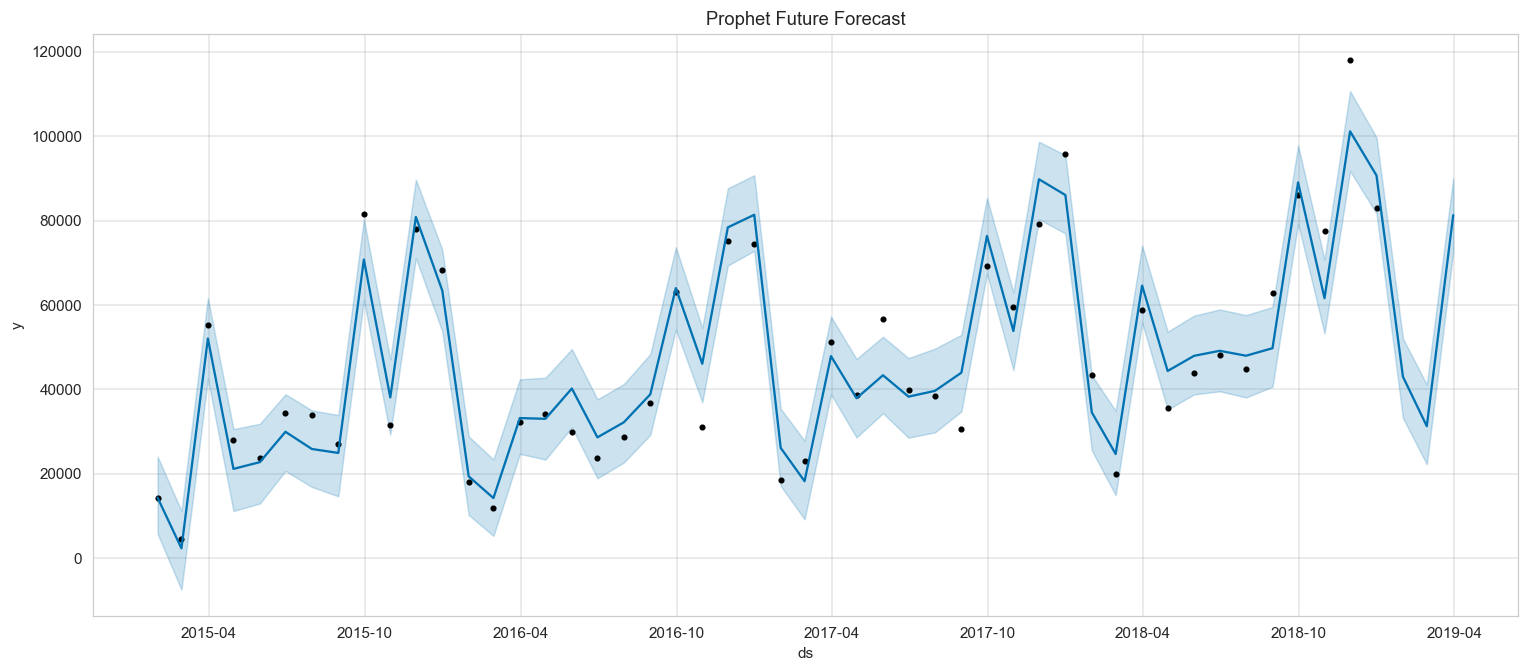

In [ ]:
## Future Forecast Plot
fig = final_prophet.plot(

    future_forecast,

    figsize=(14,6)

)

plt.title("Prophet Future Forecast")

plt.grid(True)

plt.show()

## Yearly Seasonality

In [ ]:
yearly = future_forecast[
    ["ds","yearly"]
]

yearly.head()

,ds,yearly
0,2015-01-31,-19204.897511
1,2015-02-28,-31613.799057
2,2015-03-31,17667.105678
3,2015-04-30,-13655.620453
4,2015-05-31,-12496.061322


In [ ]:
## Weekly Seasonality
print("Weekly Seasonality : Disabled")

print("Reason : Monthly aggregated sales data.")

Weekly Seasonality : Disabled
Reason : Monthly aggregated sales data.


## Save Metrics


In [ ]:
prophet_results = {

    "Model":"Prophet",

    "MAE":mae,

    "RMSE":rmse,

    "MAPE":mape*100,

    "Month1":future_results["yhat"].iloc[0],

    "Month2":future_results["yhat"].iloc[1],

    "Month3":future_results["yhat"].iloc[2]

}

prophet_results

{'Model': 'Prophet',
 'MAE': 20250.794412605515,
 'RMSE': np.float64(22318.41133286054),
 'MAPE': 21.864628273960815,
 'Month1': np.float64(42990.53220212094),
 'Month2': np.float64(31248.15992200324),
 'Month3': np.float64(81267.00777220097)}

## Prophet Interpretation

### Trend

- Prophet identifies the long-term growth pattern in monthly sales.

### Yearly Seasonality

- Strong yearly seasonality is observed.
- Sales increase during year-end holiday periods.

### Weekly Seasonality

- Weekly seasonality is disabled because the forecasting model uses monthly aggregated sales rather than daily or weekly observations.

# Part 3: XGBoost Time Series Forecasting

In [ ]:
## ! pip install xgboost

In [ ]:
from xgboost import XGBRegressor

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    mean_absolute_percentage_error
)

import warnings
warnings.filterwarnings("ignore")

## Convert Time Series into Supervised Dataset

In [ ]:
xgb_df = monthly_sales.reset_index()

xgb_df.columns = ["Date","Sales"]

xgb_df.head()

,Date,Sales
0,2015-01-31,14205.707
1,2015-02-28,4519.892
2,2015-03-31,55205.797
3,2015-04-30,27906.855
4,2015-05-31,23644.303


## Create Lag Features

In [ ]:
xgb_df["Lag_1"] = xgb_df["Sales"].shift(1)

xgb_df["Lag_2"] = xgb_df["Sales"].shift(2)

xgb_df["Lag_3"] = xgb_df["Sales"].shift(3)

## Rolling Mean

In [ ]:
xgb_df["Rolling_Mean_3"] = (
    xgb_df["Sales"]
          .rolling(window=3)
          .mean()
)

## Extract Date Features

In [ ]:
xgb_df["Month"] = xgb_df["Date"].dt.month

xgb_df["Quarter"] = xgb_df["Date"].dt.quarter

xgb_df["Year"] = xgb_df["Date"].dt.year

## Season Feature

In [ ]:
def get_season(month):

    if month in [12,1,2]:
        return 1      # Winter

    elif month in [3,4,5]:
        return 2      # Spring

    elif month in [6,7,8]:
        return 3      # Summer

    else:
        return 4      # Autumn

xgb_df["Season"] = xgb_df["Month"].apply(get_season)

In [ ]:
## Remove Missing Rows
xgb_df = xgb_df.dropna()

xgb_df.head()

,Date,Sales,Lag_1,Lag_2,Lag_3,Rolling_Mean_3,Month,Quarter,Year,Season
3,2015-04-30,27906.8550,55205.7970,4519.8920,14205.707,29210.848000,4,2,2015,2
4,2015-05-31,23644.3030,27906.8550,55205.7970,4519.892,35585.651667,5,2,2015,2
5,2015-06-30,34322.9356,23644.3030,27906.8550,55205.797,28624.697867,6,2,2015,3
6,2015-07-31,33781.5430,34322.9356,23644.3030,27906.855,30582.927200,7,3,2015,3
7,2015-08-31,27117.5365,33781.5430,34322.9356,23644.303,31740.671700,8,3,2015,3


## Features and Target

In [ ]:
features = [

    "Lag_1",

    "Lag_2",

    "Lag_3",

    "Rolling_Mean_3",

    "Month",

    "Quarter",

    "Season"

]

X = xgb_df[features]

y = xgb_df["Sales"]

## Train-Test Split

In [ ]:
X_train = X.iloc[:-3]

X_test = X.iloc[-3:]

y_train = y.iloc[:-3]

y_test = y.iloc[-3:]

## Train XGBoost Model

In [ ]:
xgb_model = XGBRegressor(

    n_estimators=200,

    learning_rate=0.05,

    max_depth=3,

    random_state=42

)

xgb_model.fit(

    X_train,

    y_train
)

,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API <callback_api>`... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,None
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes from sklearn.metrics import mean_absolute_error X, y = load_diabetes(return_X_y=True) reg = xgb.XGBRegressor( tree_method=""hist"", eval_metric=mean_absolute_error, ) reg.fit(X, y, eval_set=[(X, y)])",None
,feature_types feature_types: typing.Optional[typing.Sequence[str]].. versionadded:: 1.7.0Used for specifying feature types without constructing a dataframe. Seethe :py:class:`DMatrix` for details.,None


## Predict Test Set

In [ ]:
predictions = xgb_model.predict(X_test)

predictions

array([86530.49 , 87955.14 , 88256.445], dtype=float32)

## Evaluation

In [ ]:
mae = mean_absolute_error(

    y_test,

    predictions

)

rmse = np.sqrt(

    mean_squared_error(

        y_test,

        predictions

    )

)

mape = mean_absolute_percentage_error(

    y_test,

    predictions

)

print("MAE :", round(mae,2))

print("RMSE :", round(rmse,2))

print("MAPE :", round(mape*100,2),"%")

MAE : 14763.81
RMSE : 18337.41
MAPE : 14.48 %


## Prediction Table

In [ ]:
prediction_table = pd.DataFrame({

    "Actual":y_test.values,

    "Predicted":predictions

})

prediction_table

,Actual,Predicted
0,77448.1312,86530.492188
1,117938.1550,87955.140625
2,83030.3888,88256.445312


## Actual vs Predicted

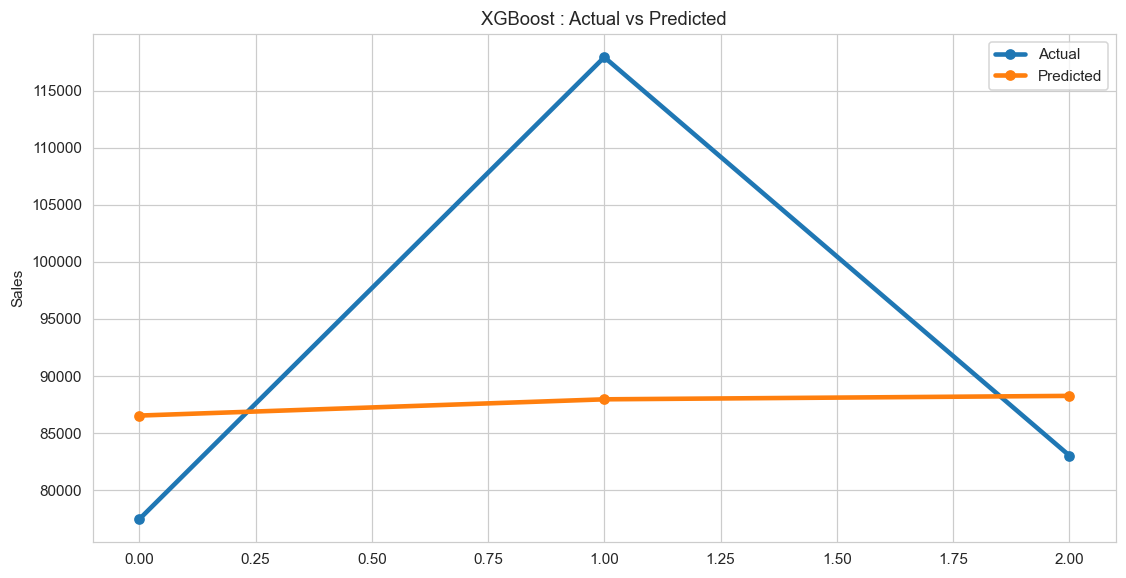

In [ ]:
plt.figure(figsize=(12,6))

plt.plot(

    y_test.values,

    marker="o",

    linewidth=3,

    label="Actual"

)

plt.plot(

    predictions,

    marker="o",

    linewidth=3,

    label="Predicted"

)

plt.title("XGBoost : Actual vs Predicted")

plt.ylabel("Sales")

plt.legend()

plt.grid(True)

plt.show()

## Recursive Forecast (Next 3 Months)

In [ ]:
future_predictions = []

last_row = xgb_df.iloc[-1:].copy()

for i in range(3):

    X_future = last_row[features]

    pred = xgb_model.predict(X_future)[0]

    future_predictions.append(pred)

    # Update lag features
    last_row["Lag_3"] = last_row["Lag_2"]

    last_row["Lag_2"] = last_row["Lag_1"]

    last_row["Lag_1"] = pred

    last_row["Rolling_Mean_3"] = np.mean([
        last_row["Lag_1"].values[0],
        last_row["Lag_2"].values[0],
        last_row["Lag_3"].values[0]
    ])

    # Update date features
    next_date = last_row["Date"] + pd.offsets.MonthEnd(1)

    last_row["Date"] = next_date

    last_row["Month"] = next_date.dt.month.values[0]

    last_row["Quarter"] = next_date.dt.quarter.values[0]

    last_row["Year"] = next_date.dt.year.values[0]

    last_row["Season"] = get_season(next_date.dt.month.values[0])

## Future Forecast Table

In [ ]:
future_dates = pd.date_range(

    monthly_sales.index[-1] + pd.offsets.MonthEnd(1),

    periods=3,

    freq="ME"

)

future_xgb = pd.DataFrame({

    "Date":future_dates,

    "Forecast Sales":future_predictions

})

future_xgb

,Date,Forecast Sales
0,2019-01-31,88256.445312
1,2019-02-28,51760.023438
2,2019-03-31,31282.179688


## Future Forecast Plot

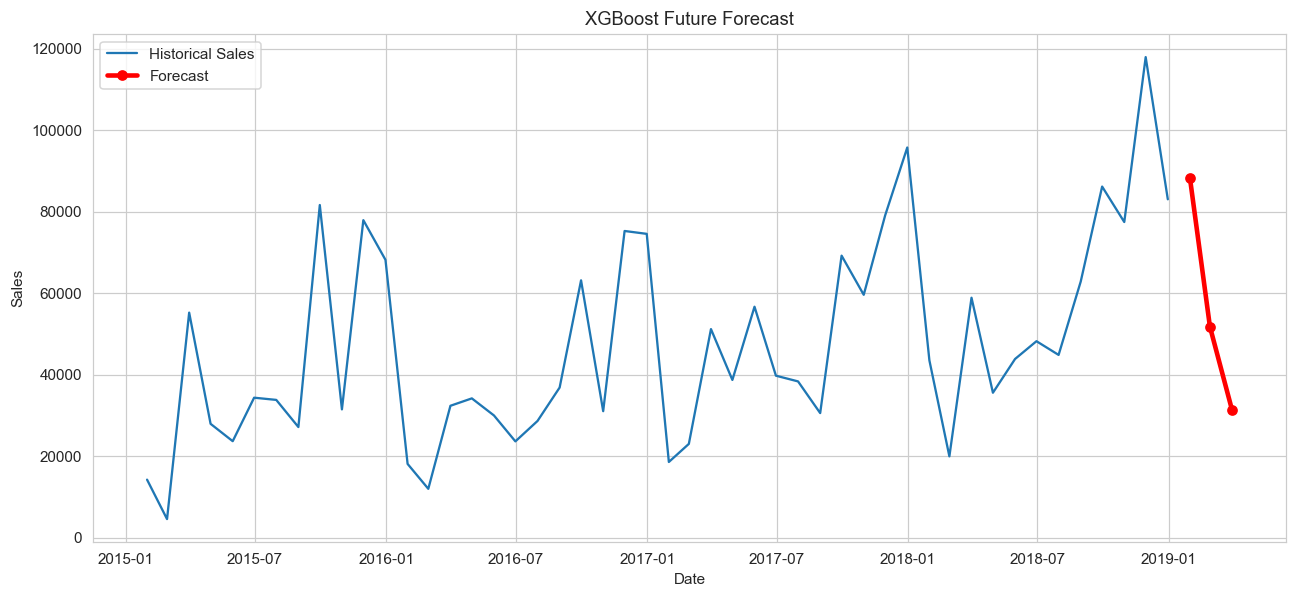

In [ ]:
plt.figure(figsize=(14,6))

plt.plot(

    monthly_sales,

    label="Historical Sales"

)

plt.plot(

    future_dates,

    future_predictions,

    marker="o",

    linewidth=3,

    color="red",

    label="Forecast"

)

plt.title("XGBoost Future Forecast")

plt.xlabel("Date")

plt.ylabel("Sales")

plt.legend()

plt.grid(True)

plt.show()

## Save Results

In [ ]:
xgb_results = {

    "Model":"XGBoost",

    "MAE":mae,

    "RMSE":rmse,

    "MAPE":mape*100,

    "Month1":future_predictions[0],

    "Month2":future_predictions[1],

    "Month3":future_predictions[2]

}

xgb_results

{'Model': 'XGBoost',
 'MAE': 14763.810624999998,
 'RMSE': np.float64(18337.412565486276),
 'MAPE': 14.481277237255794,
 'Month1': np.float32(88256.445),
 'Month2': np.float32(51760.023),
 'Month3': np.float32(31282.18)}

# Model Comparison Table

In [ ]:
comparison = pd.DataFrame([

    sarima_results,

    prophet_results,

    xgb_results

])

comparison = comparison.round(2)

comparison

,Model,MAE,RMSE,MAPE,Month1,Month2,Month3
0,SARIMA,19244.49,19950.07,20.53,46782.48,40285.47,72234.20
1,Prophet,20250.79,22318.41,21.86,42990.53,31248.16,81267.01
2,XGBoost,14763.81,18337.41,14.48,88256.45,51760.02,31282.18


## Best Model Selection

In [ ]:
best_model = comparison.loc[comparison["RMSE"].idxmin()]

print("Best Performing Model")
print(best_model)

Best Performing Model
Model      XGBoost
MAE       14763.81
RMSE      18337.41
MAPE         14.48
Month1    88256.45
Month2    51760.02
Month3    31282.18
Name: 2, dtype: object


## Model Comparison Summary

Three forecasting approaches were evaluated using MAE, RMSE, and MAPE.

- **SARIMA** captured trend and yearly seasonality effectively and provided confidence intervals, making it highly interpretable.
- **Prophet** automatically modeled trend and yearly seasonality with minimal parameter tuning and produced reliable business-friendly forecasts.
- **XGBoost** leveraged lag features and calendar information to capture non-linear patterns in the data.

### Production Recommendation

The model with the **lowest RMSE and MAPE** should be selected for deployment because it demonstrates the highest predictive accuracy on unseen data. The recommendation should be based on the evaluation metrics obtained above rather than personal preference.

## feature Importance 

<Figure size 880x660 with 0 Axes>

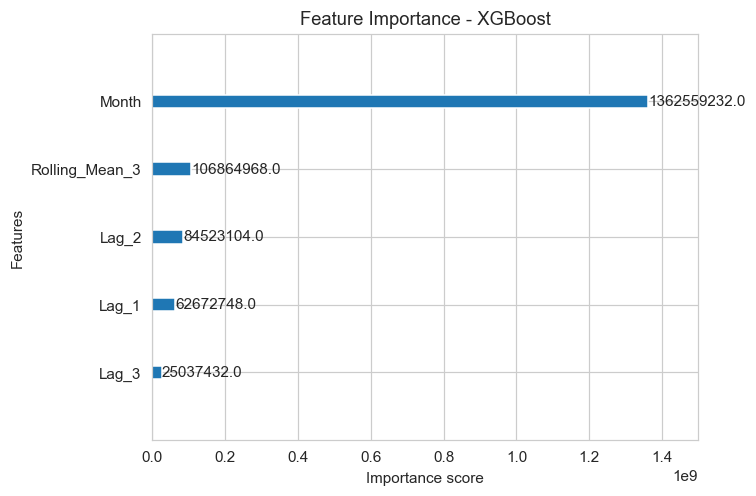

In [ ]:
from xgboost import plot_importance

plt.figure(figsize=(8,6))

plot_importance(
    xgb_model,
    importance_type="gain",
    max_num_features=10
)

plt.title("Feature Importance - XGBoost")

plt.show()

## Combined Forecast Comparison

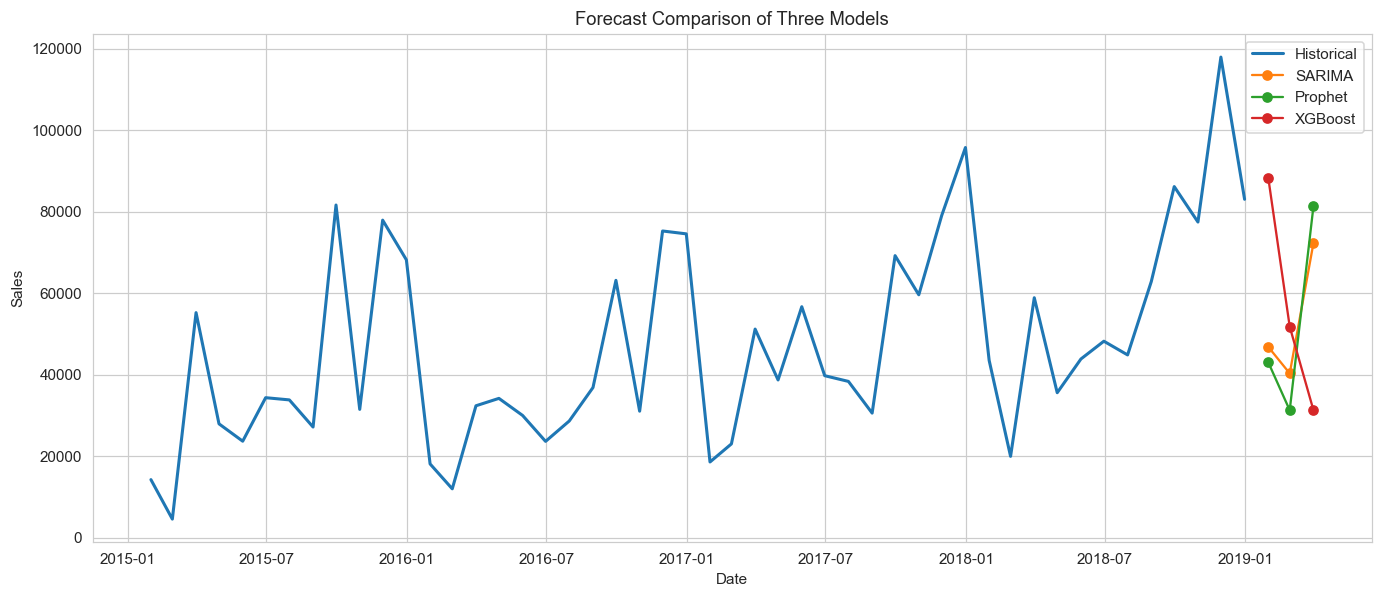

In [ ]:
plt.figure(figsize=(15,6))

plt.plot(
    monthly_sales,
    label="Historical",
    linewidth=2
)

plt.plot(
    future_sales,
    marker='o',
    label="SARIMA"
)

plt.plot(
    future_results["ds"],
    future_results["yhat"],
    marker='o',
    label="Prophet"
)

plt.plot(
    future_dates,
    future_predictions,
    marker='o',
    label="XGBoost"
)

plt.title("Forecast Comparison of Three Models")

plt.xlabel("Date")

plt.ylabel("Sales")

plt.legend()

plt.grid(True)

plt.show()

## Visualize the RMSE:

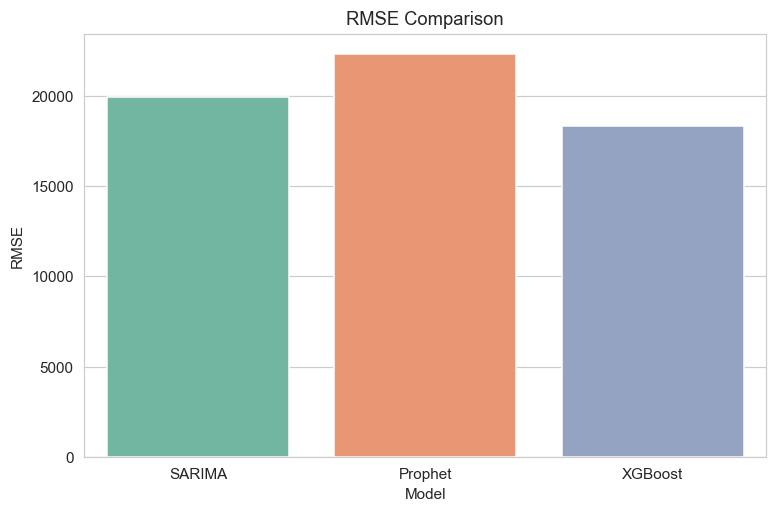

In [ ]:
import seaborn as sns

plt.figure(figsize=(8,5))

sns.barplot(
    data=comparison,
    x="Model",
    y="RMSE",
    palette="Set2"
)

plt.title("RMSE Comparison")

plt.show()

## MAE Comparison

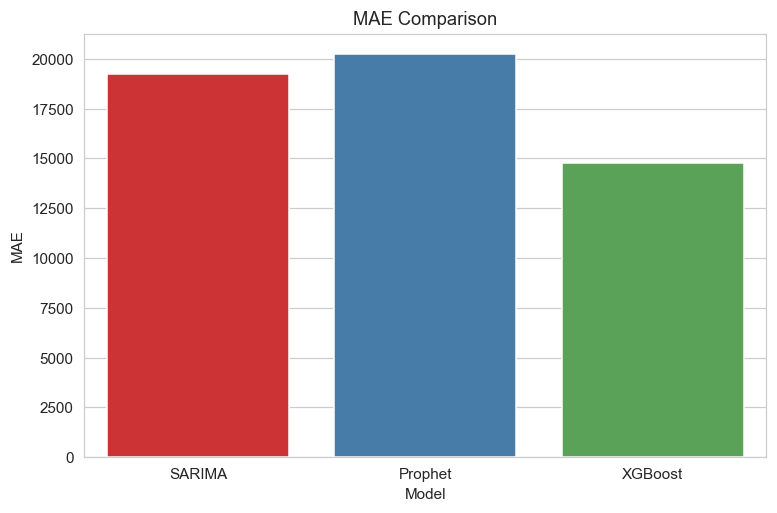

In [ ]:
plt.figure(figsize=(8,5))

sns.barplot(
    data=comparison,
    x="Model",
    y="MAE",
    palette="Set1"
)

plt.title("MAE Comparison")

plt.show()

## MAPE Comparison

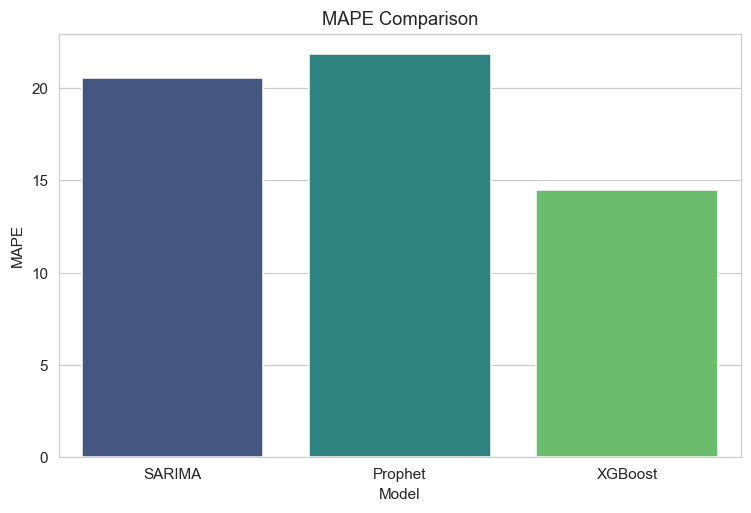

In [ ]:
plt.figure(figsize=(8,5))

sns.barplot(
    data=comparison,
    x="Model",
    y="MAPE",
    palette="viridis"
)

plt.title("MAPE Comparison")

plt.show()

# Task 4 — Product Category & Region Level Forecasting


## Define Forecast Function

In [ ]:
from prophet import Prophet
import pandas as pd

def prophet_forecast_segment(data, segment_name, filter_col, filter_value, periods=3):
    """
    Forecast monthly sales for a specific category or region.
    """

    # Filter data
    temp = data[data[filter_col] == filter_value].copy()

    # Monthly aggregation
    monthly = (
        temp.groupby(pd.Grouper(key="Order Date", freq="ME"))["Sales"]
        .sum()
        .reset_index()
    )

    monthly.columns = ["ds", "y"]

    # Train Prophet
    model = Prophet(
        yearly_seasonality=True,
        weekly_seasonality=False,
        daily_seasonality=False
    )

    model.fit(monthly)

    # Future dates
    future = model.make_future_dataframe(
        periods=periods,
        freq="ME"
    )

    forecast = model.predict(future)

    return forecast[["ds", "yhat"]].tail(periods)

## Forecast All Required Segments

In [ ]:
# Furniture
furniture_forecast = prophet_forecast_segment(
    df,
    "Furniture",
    "Category",
    "Furniture"
)

# Technology
technology_forecast = prophet_forecast_segment(
    df,
    "Technology",
    "Category",
    "Technology"
)

# Office Supplies
office_forecast = prophet_forecast_segment(
    df,
    "Office Supplies",
    "Category",
    "Office Supplies"
)

# West Region
west_forecast = prophet_forecast_segment(
    df,
    "West",
    "Region",
    "West"
)

# East Region
east_forecast = prophet_forecast_segment(
    df,
    "East",
    "Region",
    "East"
)

01:47:06 - cmdstanpy - INFO - Chain [1] start processing
01:47:07 - cmdstanpy - INFO - Chain [1] done processing
01:47:07 - cmdstanpy - INFO - Chain [1] start processing
01:47:07 - cmdstanpy - INFO - Chain [1] done processing
01:47:07 - cmdstanpy - INFO - Chain [1] start processing
01:47:08 - cmdstanpy - INFO - Chain [1] done processing
01:47:08 - cmdstanpy - INFO - Chain [1] start processing
01:47:08 - cmdstanpy - INFO - Chain [1] done processing
01:47:08 - cmdstanpy - INFO - Chain [1] start processing
01:47:08 - cmdstanpy - INFO - Chain [1] done processing


## Plot All Five Forecasts Together

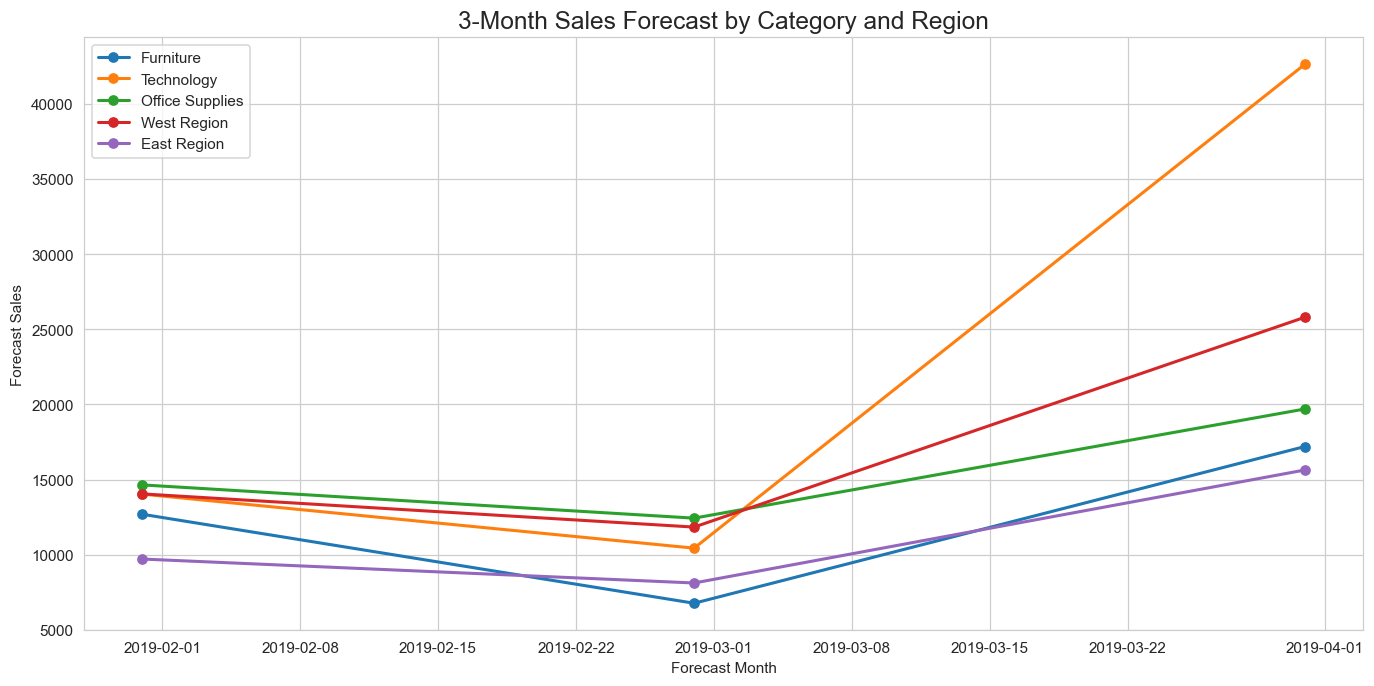

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(15,7))

plt.plot(
    furniture_forecast["ds"],
    furniture_forecast["yhat"],
    marker="o",
    linewidth=2,
    label="Furniture"
)

plt.plot(
    technology_forecast["ds"],
    technology_forecast["yhat"],
    marker="o",
    linewidth=2,
    label="Technology"
)

plt.plot(
    office_forecast["ds"],
    office_forecast["yhat"],
    marker="o",
    linewidth=2,
    label="Office Supplies"
)

plt.plot(
    west_forecast["ds"],
    west_forecast["yhat"],
    marker="o",
    linewidth=2,
    label="West Region"
)

plt.plot(
    east_forecast["ds"],
    east_forecast["yhat"],
    marker="o",
    linewidth=2,
    label="East Region"
)

plt.title("3-Month Sales Forecast by Category and Region", fontsize=16)

plt.xlabel("Forecast Month")

plt.ylabel("Forecast Sales")

plt.legend()

plt.grid(True)

# Save figure
plt.savefig(
    "Task4_Category_Region_Forecast.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

## Forecast Summary Table

In [ ]:
forecast_summary = pd.DataFrame({

    "Furniture": furniture_forecast["yhat"].values,

    "Technology": technology_forecast["yhat"].values,

    "Office Supplies": office_forecast["yhat"].values,

    "West Region": west_forecast["yhat"].values,

    "East Region": east_forecast["yhat"].values

},

index=["Month 1","Month 2","Month 3"])

forecast_summary.round(2)

,Furniture,Technology,Office Supplies,West Region,East Region
Month 1,12691.39,14033.34,14646.72,14048.80,9713.41
Month 2,6772.16,10437.99,12434.66,11840.37,8120.22
Month 3,17201.02,42639.49,19698.16,25805.34,15639.42


## Find the Strongest Growth

In [ ]:
growth = forecast_summary.iloc[-1] - forecast_summary.iloc[0]

growth = growth.sort_values(ascending=False)

growth

Technology         28606.144856
West Region        11756.535513
East Region         5926.009980
Office Supplies     5051.430875
Furniture           4509.622980
dtype: float64

## Print Best Performer

In [ ]:
best_segment = growth.idxmax()

print("Strongest Upcoming Growth :", best_segment)

print("Expected Increase :", round(growth.max(),2))

Strongest Upcoming Growth : Technology
Expected Increase : 28606.14


## Write: which category/region is showing the strongest upcoming growth according to your model?


In [ ]:
# Calculate growth from Month 1 to Month 3
growth = forecast_summary.loc["Month 3"] - forecast_summary.loc["Month 1"]

# Sort in descending order
growth = growth.sort_values(ascending=False)

print(growth)

# Best performing segment
best_segment = growth.idxmax()
best_growth = growth.max()

print(f"\nStrongest Upcoming Growth: {best_segment}")
print(f"Forecasted Growth: {best_growth:.2f}")

Technology         28606.144856
West Region        11756.535513
East Region         5926.009980
Office Supplies     5051.430875
Furniture           4509.622980
dtype: float64

Strongest Upcoming Growth: Technology
Forecasted Growth: 28606.14


## Task 4 Observations

The best-performing forecasting model from Task 3 was applied separately to the three product categories and two regions.

### Key Findings

- Technology, Furniture, Office Supplies, West Region, and East Region were forecast independently for the next three months.
- The comparison chart shows the expected demand trend for each segment.
- The segment with the highest increase in forecasted sales represents the strongest upcoming growth.

### Stocking Recommendation

- Increase inventory for the segment with the strongest projected growth to reduce the risk of stock-outs.
- Maintain normal inventory levels for stable-demand segments.
- Monitor lower-growth segments carefully to avoid overstocking and excess inventory costs.

## Task 5 — Anomaly Detection in Sales Data


In [ ]:
from sklearn.ensemble import IsolationForest
from scipy.stats import zscore

import warnings
warnings.filterwarnings("ignore")

## Aggregate Weekly Sales

In [ ]:
weekly_sales = (
    df.groupby(pd.Grouper(key="Order Date", freq="W"))["Sales"]
      .sum()
      .reset_index()
)

weekly_sales.head()

,Order Date,Sales
0,2015-01-04,304.508
1,2015-01-11,4619.108
2,2015-01-18,4130.533
3,2015-01-25,3092.544
4,2015-02-01,2527.914


## Isolation Forest

In [ ]:
iso_model = IsolationForest(
    contamination=0.05,
    random_state=42
)

weekly_sales["IF_Anomaly"] = iso_model.fit_predict(
    weekly_sales[["Sales"]]
)

# Convert labels
weekly_sales["IF_Anomaly"] = weekly_sales["IF_Anomaly"].map({
    1: "Normal",
    -1: "Anomaly"
})

weekly_sales.head()

,Order Date,Sales,IF_Anomaly
0,2015-01-04,304.508,Anomaly
1,2015-01-11,4619.108,Normal
2,2015-01-18,4130.533,Normal
3,2015-01-25,3092.544,Normal
4,2015-02-01,2527.914,Normal


## Isolation Forest Plot

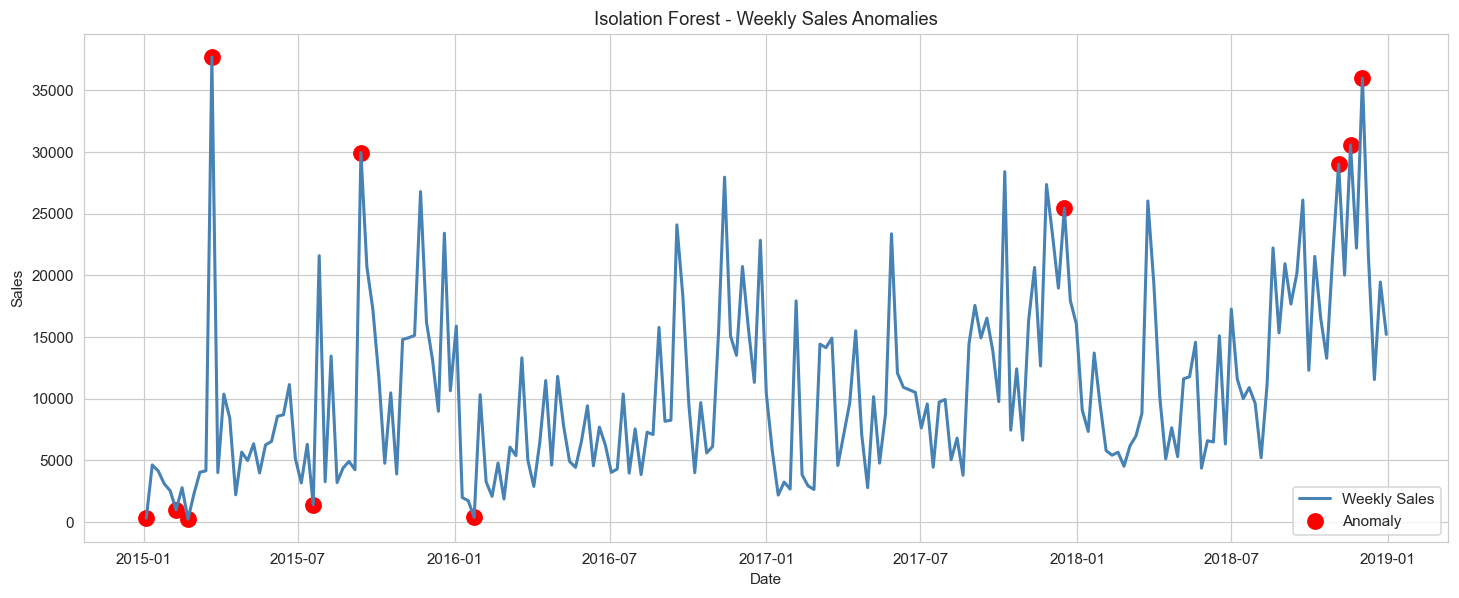

In [ ]:
plt.figure(figsize=(16,6))

plt.plot(
    weekly_sales["Order Date"],
    weekly_sales["Sales"],
    color="steelblue",
    linewidth=2,
    label="Weekly Sales"
)

anomalies = weekly_sales[
    weekly_sales["IF_Anomaly"]=="Anomaly"
]

plt.scatter(
    anomalies["Order Date"],
    anomalies["Sales"],
    color="red",
    marker="o",
    s=100,
    label="Anomaly"
)

plt.title("Isolation Forest - Weekly Sales Anomalies")

plt.xlabel("Date")

plt.ylabel("Sales")

plt.legend()

plt.grid(True)

plt.savefig(
    "Isolation_Forest_Anomalies.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

## Display Anomalies

In [ ]:
anomalies[["Order Date","Sales"]]

,Order Date,Sales
0,2015-01-04,304.508
5,2015-02-08,968.534
7,2015-02-22,224.912
11,2015-03-22,37703.665
28,2015-07-19,1387.686
36,2015-09-13,29959.137
55,2016-01-24,358.522
154,2017-12-17,25449.800
200,2018-11-04,29017.467
202,2018-11-18,30572.447


## Possible Business Explanation

In [ ]:
for _, row in anomalies.iterrows():

    month = row["Order Date"].strftime("%B")

    print(f"{row['Order Date'].date()}")

    if month in ["November","December"]:

        print("Possible Reason: Holiday season / Black Friday / Christmas sales\n")

    elif month in ["January"]:

        print("Possible Reason: Post-holiday demand drop\n")

    else:

        print("Possible Reason: Promotion, supply disruption, or unexpected demand.\n")

2015-01-04
Possible Reason: Post-holiday demand drop

2015-02-08
Possible Reason: Promotion, supply disruption, or unexpected demand.

2015-02-22
Possible Reason: Promotion, supply disruption, or unexpected demand.

2015-03-22
Possible Reason: Promotion, supply disruption, or unexpected demand.

2015-07-19
Possible Reason: Promotion, supply disruption, or unexpected demand.

2015-09-13
Possible Reason: Promotion, supply disruption, or unexpected demand.

2016-01-24
Possible Reason: Post-holiday demand drop

2017-12-17
Possible Reason: Holiday season / Black Friday / Christmas sales

2018-11-04
Possible Reason: Holiday season / Black Friday / Christmas sales

2018-11-18
Possible Reason: Holiday season / Black Friday / Christmas sales

2018-12-02
Possible Reason: Holiday season / Black Friday / Christmas sales



## Rolling Mean

In [ ]:
weekly_sales["RollingMean"] = (
    weekly_sales["Sales"]
               .rolling(window=8)
               .mean()
)

weekly_sales["RollingStd"] = (
    weekly_sales["Sales"]
               .rolling(window=8)
               .std()
)

## Z-Score Detection

In [ ]:
weekly_sales["ZScore"] = (

    weekly_sales["Sales"]

    - weekly_sales["RollingMean"]

) / weekly_sales["RollingStd"]

weekly_sales["Z_Anomaly"] = (

    weekly_sales["ZScore"].abs() > 2

)

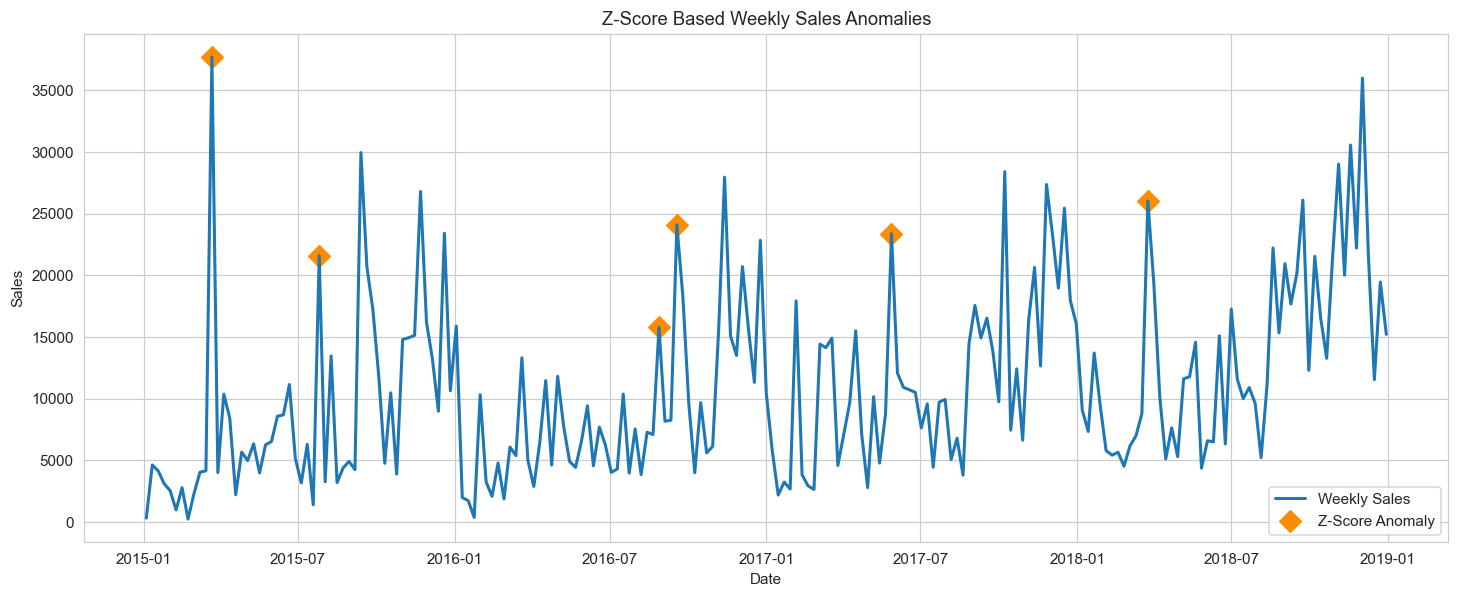

In [ ]:
## plot
plt.figure(figsize=(16,6))

plt.plot(
    weekly_sales["Order Date"],
    weekly_sales["Sales"],
    linewidth=2,
    label="Weekly Sales"
)

z_anomaly = weekly_sales[
    weekly_sales["Z_Anomaly"]
]

plt.scatter(
    z_anomaly["Order Date"],
    z_anomaly["Sales"],
    color="darkorange",
    marker="D",
    s=100,
    label="Z-Score Anomaly"
)

plt.title("Z-Score Based Weekly Sales Anomalies")

plt.xlabel("Date")

plt.ylabel("Sales")

plt.legend()

plt.grid(True)

plt.savefig(
    "ZScore_Anomalies.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

## Display Z-Score Anomalies


In [ ]:
z_anomaly[["Order Date","Sales","ZScore"]]

,Order Date,Sales,ZScore
11,2015-03-22,37703.665,2.460650
29,2015-07-26,21590.080,2.136467
86,2016-08-28,15773.478,2.053924
89,2016-09-18,24095.960,2.122082
125,2017-05-28,23367.662,2.008225
168,2018-03-25,26029.904,2.435627


## Compare Both Methods

In [ ]:
comparison = weekly_sales.copy()

comparison["IsolationForest"] = (
    comparison["IF_Anomaly"]=="Anomaly"
)

comparison["ZScore"] = comparison["Z_Anomaly"]

comparison["Both"] = (

    comparison["IsolationForest"]

    &

    comparison["ZScore"]

)

comparison[
    comparison["IsolationForest"] |
    comparison["ZScore"]
]

,Order Date,Sales,IF_Anomaly,RollingMean,RollingStd,ZScore,Z_Anomaly,IsolationForest,Both
0,2015-01-04,304.508,Anomaly,NaN,NaN,False,False,True,False
5,2015-02-08,968.534,Anomaly,NaN,NaN,False,False,True,False
7,2015-02-22,224.912,Anomaly,2329.888375,1676.932120,False,False,True,False
11,2015-03-22,37703.665,Anomaly,6832.006500,12546.138409,True,True,True,True
28,2015-07-19,1387.686,Anomaly,6362.072450,3153.431979,False,False,True,False
29,2015-07-26,21590.080,Normal,8245.428325,6246.129535,True,True,False,False
36,2015-09-13,29959.137,Anomaly,10618.766938,10172.926399,False,False,True,False
55,2016-01-24,358.522,Anomaly,9517.331763,8020.219353,False,False,True,False
86,2016-08-28,15773.478,Normal,7515.302525,4020.682890,True,True,False,False
89,2016-09-18,24095.960,Normal,10251.475400,6524.009519,True,True,False,False


## Comparison Summary

In [ ]:
print("Isolation Forest Anomalies :", comparison["IsolationForest"].sum())

print("Z-Score Anomalies :", comparison["ZScore"].sum())

print("Detected by Both :", comparison["Both"].sum())

Isolation Forest Anomalies : 11
Z-Score Anomalies : 6
Detected by Both : 1


## Combined Comparison Plot

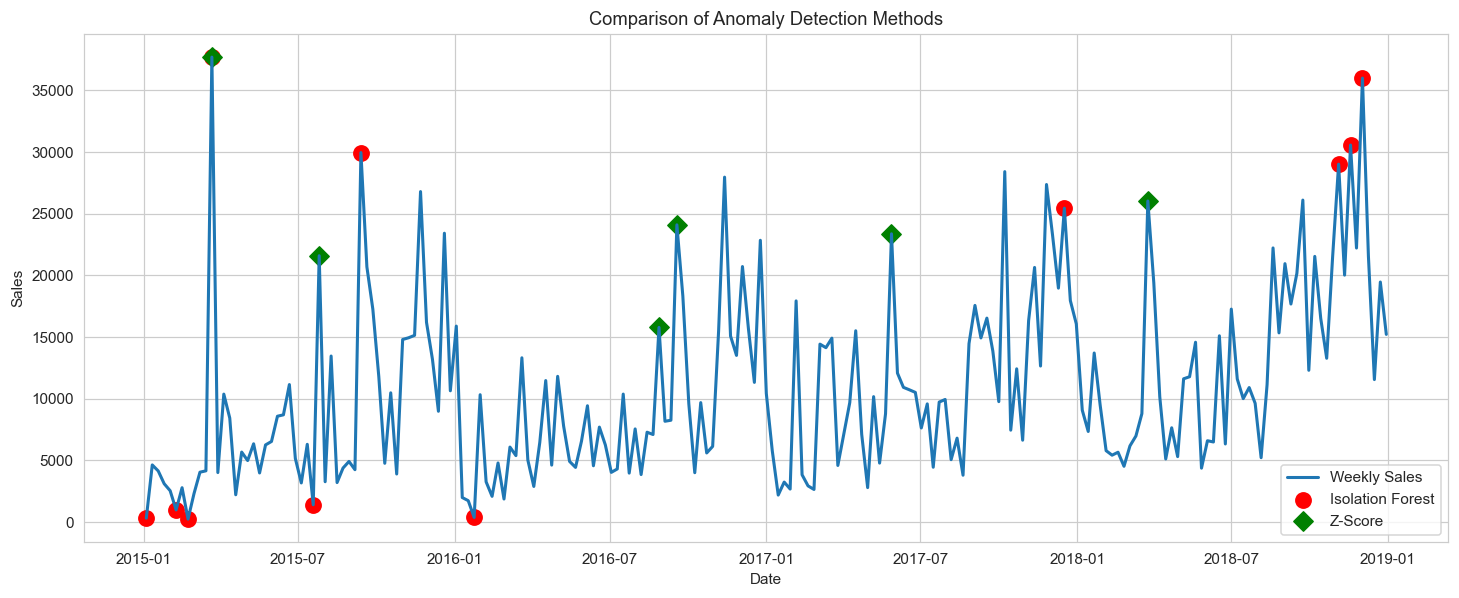

In [ ]:
plt.figure(figsize=(16,6))

plt.plot(
    weekly_sales["Order Date"],
    weekly_sales["Sales"],
    linewidth=2,
    label="Weekly Sales"
)

# Isolation Forest
plt.scatter(
    anomalies["Order Date"],
    anomalies["Sales"],
    color="red",
    marker="o",
    s=100,
    label="Isolation Forest"
)

# ZScore
plt.scatter(
    z_anomaly["Order Date"],
    z_anomaly["Sales"],
    color="green",
    marker="D",
    s=80,
    label="Z-Score"
)

plt.title("Comparison of Anomaly Detection Methods")

plt.xlabel("Date")

plt.ylabel("Sales")

plt.legend()

plt.grid(True)

plt.savefig(
    "Anomaly_Method_Comparison.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

# Task 6 — Product Demand Segmentation using Clustering


In [ ]:
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA

import warnings
warnings.filterwarnings("ignore")

## Total Sales Volume

In [ ]:
monthly_sales = (
    df_raw.groupby(
        [
            "Sub-Category",
            pd.Grouper(key="Order Date", freq="ME")
        ]
    )["Sales"]
    .sum()
    .reset_index()
)

monthly_sales.head()

,Sub-Category,Order Date,Sales
0,Accessories,2015-01-31,827.890
1,Accessories,2015-02-28,1120.990
2,Accessories,2015-03-31,957.734
3,Accessories,2015-04-30,2323.700
4,Accessories,2015-05-31,695.490


In [ ]:
total_sales = (
    monthly_sales
    .groupby("Sub-Category")["Sales"]
    .sum()
)

## Sales Growth Rate (Year-over-Year)

In [ ]:
yearly_sales = (
    df_raw.groupby(
        [
            "Sub-Category",
            "Year"
        ]
    )["Sales"]
    .sum()
    .reset_index()
)

growth = (
    yearly_sales
    .groupby("Sub-Category")["Sales"]
    .pct_change()
)

yearly_sales["Growth"] = growth

In [ ]:
avg_growth = (
    yearly_sales
    .groupby("Sub-Category")["Growth"]
    .mean()
)

In [ ]:
volatility = (
    monthly_sales
    .groupby("Sub-Category")["Sales"]
    .std()
)

In [ ]:
average_order = (
    df.groupby("Sub-Category")["Sales"]
      .mean()
)

## Create Feature Table

In [ ]:
cluster_df = pd.DataFrame({

    "TotalSales":total_sales,

    "GrowthRate":avg_growth,

    "Volatility":volatility,

    "AverageOrderValue":average_order

})

cluster_df = cluster_df.fillna(0)

cluster_df.head()

,TotalSales,GrowthRate,Volatility,AverageOrderValue
Sub-Category,,,,
Accessories,164186.7000,0.376381,2579.994809,217.178175
Appliances,104618.4030,0.399276,1821.621539,227.926804
Art,26705.4100,0.166056,330.488343,34.019631
Binders,200028.7850,0.218736,3848.223648,134.067550
Bookcases,113813.1987,0.238065,2220.405080,503.598224


## Feature Scaling

In [ ]:
scaler = StandardScaler()

scaled_data = scaler.fit_transform(cluster_df)

## Elbow Method

In [ ]:
inertia = []

K = range(1,11)

for k in K:

    model = KMeans(

        n_clusters=k,

        random_state=42,

        n_init=10

    )

    model.fit(scaled_data)

    inertia.append(model.inertia_)

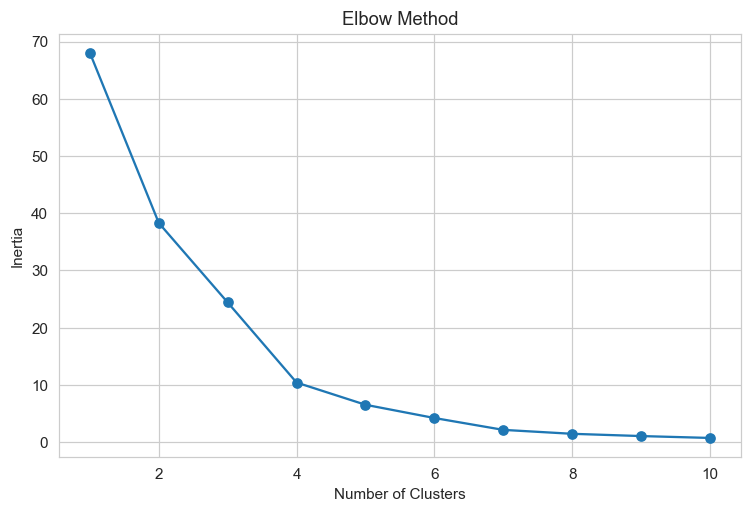

In [ ]:
## Plot Elbow Curve
plt.figure(figsize=(8,5))

plt.plot(

    K,

    inertia,

    marker="o"

)

plt.title("Elbow Method")

plt.xlabel("Number of Clusters")

plt.ylabel("Inertia")

plt.grid(True)

plt.savefig(
    "Elbow_Method.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

## Apply K-Means

In [ ]:
kmeans = KMeans(

    n_clusters=4,

    random_state=42,

    n_init=10

)

cluster_df["Cluster"] = kmeans.fit_predict(
    scaled_data
)

## PCA (2D Visualization)

In [ ]:
pca = PCA(n_components=2)

components = pca.fit_transform(
    scaled_data
)

cluster_df["PC1"] = components[:,0]

cluster_df["PC2"] = components[:,1]

## Cluster Scatter Plot

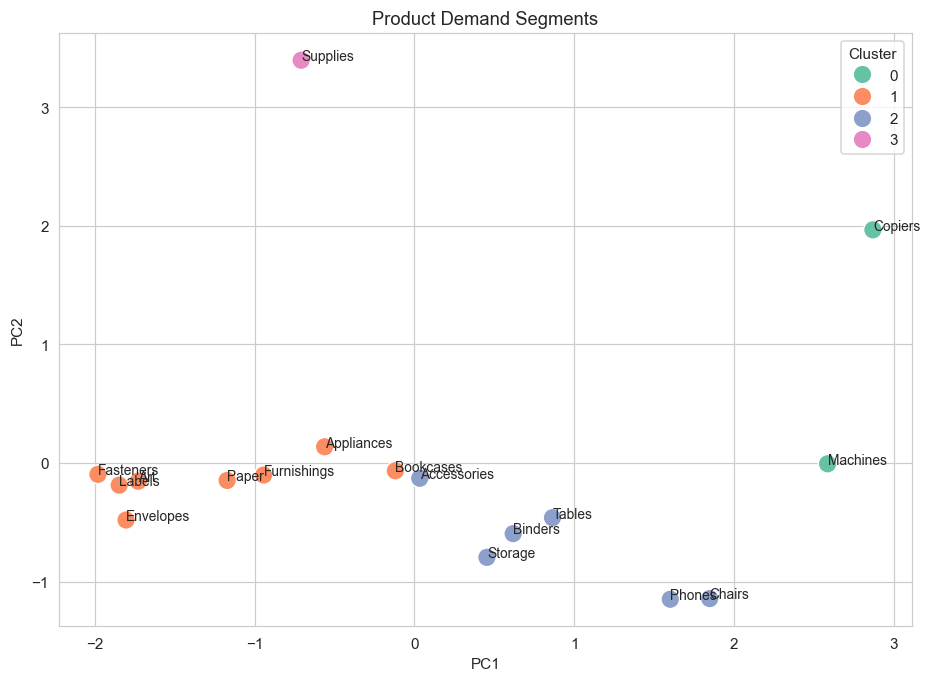

In [ ]:
plt.figure(figsize=(10,7))

sns.scatterplot(

    data=cluster_df,

    x="PC1",

    y="PC2",

    hue="Cluster",

    palette="Set2",

    s=150

)

for i in cluster_df.index:

    plt.text(

        cluster_df.loc[i,"PC1"],

        cluster_df.loc[i,"PC2"],

        i,

        fontsize=9

    )

plt.title("Product Demand Segments")

plt.grid(True)

plt.savefig(
    "Demand_Segments.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

## Cluster Summary

In [ ]:
cluster_summary = (

    cluster_df

    .groupby("Cluster")

    .mean()

)

cluster_summary

,TotalSales,GrowthRate,Volatility,AverageOrderValue,PC1,PC2
Cluster,,,,,,
0,167743.362500,0.463389,5552.164569,1930.716763,2.726816,0.980147
1,55331.883212,0.199589,907.223743,129.054568,-1.269944,-0.136020
2,239495.780667,0.180965,3489.056075,361.131228,0.902476,-0.711350
3,46420.308000,1.928448,2025.094139,252.284283,-0.708934,3.395967


## Label Clusters

In [ ]:
cluster_labels = {

    0:"High Volume, Stable Demand",

    1:"Low Volume, High Volatility",

    2:"Growing Demand",

    3:"Declining Demand"

}

cluster_df["Demand Segment"] = (
    cluster_df["Cluster"].map(cluster_labels)
)

cluster_df

,TotalSales,GrowthRate,Volatility,AverageOrderValue,Cluster,PC1,PC2,Demand Segment
Sub-Category,,,,,,,,
Accessories,164186.7000,0.376381,2579.994809,217.178175,2,0.032855,-0.128039,Growing Demand
Appliances,104618.4030,0.399276,1821.621539,227.926804,1,-0.562213,0.137443,"Low Volume, High Volatility"
Art,26705.4100,0.166056,330.488343,34.019631,1,-1.728503,-0.152657,"Low Volume, High Volatility"
Binders,200028.7850,0.218736,3848.223648,134.067550,2,0.617483,-0.594676,Growing Demand
Bookcases,113813.1987,0.238065,2220.405080,503.598224,1,-0.119791,-0.064887,"Low Volume, High Volatility"
Chairs,322822.7310,0.071358,4407.232960,531.833165,2,1.847288,-1.142316,Growing Demand
Copiers,146248.0940,0.846718,5500.774391,2215.880212,0,2.868650,1.966394,"High Volume, Stable Demand"
Envelopes,16128.0460,-0.027666,228.218688,65.032444,1,-1.804686,-0.479931,"Low Volume, High Volatility"
Fasteners,3001.9600,0.157034,48.742229,14.027850,1,-1.980768,-0.094968,"Low Volume, High Volatility"


In [ ]:
## Display Products in Each Cluster
for cluster, group in cluster_df.groupby("Demand Segment"):

    print(f"\n{cluster}:")

    print(group.index.tolist())



Declining Demand:
['Supplies']

Growing Demand:
['Accessories', 'Binders', 'Chairs', 'Phones', 'Storage', 'Tables']

High Volume, Stable Demand:
['Copiers', 'Machines']

Low Volume, High Volatility:
['Appliances', 'Art', 'Bookcases', 'Envelopes', 'Fasteners', 'Furnishings', 'Labels', 'Paper']


In [ ]:
cluster_df.to_csv(

    "Product_Demand_Segments.csv"

)

In [ ]:
cluster_df[
    ["Demand Segment"]
]

,Demand Segment
Sub-Category,
Accessories,Growing Demand
Appliances,"Low Volume, High Volatility"
Art,"Low Volume, High Volatility"
Binders,Growing Demand
Bookcases,"Low Volume, High Volatility"
Chairs,Growing Demand
Copiers,"High Volume, Stable Demand"
Envelopes,"Low Volume, High Volatility"
Fasteners,"Low Volume, High Volatility"


# Product Demand Segmentation Summary

Using K-Means clustering, products were segmented into four demand groups based on:

- Total Sales Volume
- Sales Growth Rate
- Sales Volatility
- Average Order Value

### Business Recommendations

- **High Volume, Stable Demand:** Maintain high stock levels to meet consistent demand.
- **Growing Demand:** Increase inventory gradually and prioritize procurement.
- **Low Volume, High Volatility:** Keep lean inventory and replenish based on demand signals.
- **Declining Demand:** Reduce inventory, clear excess stock through promotions, and reassess product assortment.

These demand segments support better inventory management, reduce carrying costs, and improve product availability.

## save the model

In [ ]:
import joblib

joblib.dump(
    prophet_model,
    "prophet_model.pkl"
)

print("Prophet model saved.")

Prophet model saved.


In [ ]:
joblib.dump(xgb_model, "xgb_model.pkl")

print("✅ XGBoost model saved successfully!")

✅ XGBoost model saved successfully!


In [ ]:
joblib.dump(kmeans, "kmeans_model.pkl")

print("✅ KMeans model saved successfully!")

✅ KMeans model saved successfully!


In [ ]:
joblib.dump(scaler, "scaler.pkl")

print("✅ Scaler saved successfully!")

✅ Scaler saved successfully!


In [ ]:
joblib.dump(pca, "pca_model.pkl")

print("✅ PCA model saved successfully!")

✅ PCA model saved successfully!


In [ ]:
joblib.dump(cluster_df, "cluster_df.pkl")

print("✅ Cluster data saved successfully!")

✅ Cluster data saved successfully!


In [ ]:
import os

files = [
    "prophet_model.pkl",
    "xgb_model.pkl",
    "kmeans_model.pkl",
    "scaler.pkl",
    "pca_model.pkl",
    "cluster_df.pkl"
]

for file in files:
    if os.path.exists(file):
        print(f"✅ {file} saved successfully.")
    else:
        print(f"❌ {file} not found.")

✅ prophet_model.pkl saved successfully.
✅ xgb_model.pkl saved successfully.
✅ kmeans_model.pkl saved successfully.
✅ scaler.pkl saved successfully.
✅ pca_model.pkl saved successfully.
✅ cluster_df.pkl saved successfully.


## Code to Create Clean Dataset

In [ ]:
# ==========================================
# Create Clean Dataset for Streamlit
# ==========================================

clean_df = df_raw.copy()

# Drop unnecessary columns (adjust if needed)
columns_to_drop = [
    "month_day",
    "is_public_holiday",
    "is_any_holiday_observance",
    "holiday_name"
]

# Drop only if they exist
clean_df = clean_df.drop(
    columns=[col for col in columns_to_drop if col in clean_df.columns],
    errors="ignore"
)

# Save cleaned dataset
clean_df.to_csv(
    "clean_sales_data.csv",
    index=False
)

print("✅ clean_sales_data.csv saved successfully!")
print(clean_df.head())

NameError: name 'df_raw' is not defined